# Guia 04: Redes Neuronales Profundas (DNN) en Problemas Reales

## Electiva II - Deep Learning | Tecnologico de Antioquia

---

**Objetivo:** Aplicar redes neuronales profundas a datos tabulares del mundo real, aprender a preprocesar datos reales y gestionar el ciclo de vida completo del modelo (entrenar, guardar, cargar, predecir).

**Conceptos nuevos en esta guia:**
- Preprocesamiento de datos tabulares para DNN
- Feature engineering basico
- Normalizacion vs estandarizacion
- Manejo de variables categoricas (One-Hot Encoding, Label Encoding)
- Callbacks avanzados: `ModelCheckpoint`, `ReduceLROnPlateau`, `CSVLogger`, `TensorBoard`
- Guardado y carga de modelos
- DNN para regresion
- Comparacion DNN vs Machine Learning clasico

**Prerrequisito:** Guia 03 - Optimizacion y Regularizacion

**Duracion estimada:** 3 horas

---

> **Aviso de evaluacion** \u270d\ufe0f: A lo largo de esta guia encontraras preguntas marcadas con \u270d\ufe0f que debes responder. Estas preguntas seran evaluadas y forman parte de tu nota. Responde de manera completa y reflexiva.

---
## 1. Configuracion del Entorno

Importamos todas las librerias necesarias y fijamos la semilla para reproducibilidad.

In [1]:
# ============================================================
# Importaciones principales
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow y Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, models

# Scikit-learn: preprocesamiento y metricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, accuracy_score
)

# Scikit-learn: modelos clasicos para comparacion
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Utilidades
import os
import json
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Semilla para reproducibilidad
# ============================================================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuracion de graficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("Entorno configurado correctamente.")

TensorFlow version: 2.19.0
NumPy version: 2.0.2
Pandas version: 2.2.2
Entorno configurado correctamente.


---
## 2. Marco Teorico

### 2.1 De imagenes a datos tabulares: \u00bfpor que son diferentes?

En las guias anteriores trabajamos con datasets de imagenes (MNIST, Fashion-MNIST). Los datos tabulares presentan desafios diferentes:

| Caracteristica | Imagenes | Datos Tabulares |
|---|---|---|
| Tipo de features | Pixeles (homogeneos, 0-255) | Mixtos (numericos, categoricos) |
| Escala | Todos en la misma escala | Escalas muy diferentes |
| Relacion espacial | Los pixeles vecinos estan relacionados | Las columnas pueden ser independientes |
| Preprocesamiento | Simple (dividir por 255) | Complejo (normalizacion, encoding, missing values) |
| Cantidad de datos | Tipicamente muchos (miles/millones) | A veces pocos (cientos) |
| DL vs ML clasico | DL suele ganar | ML clasico puede ganar |

**Punto clave:** Con datos tabulares, el preprocesamiento es tan importante (o mas) que la arquitectura de la red.

### 2.2 Preprocesamiento para Redes Neuronales

#### Normalizacion vs Estandarizacion

Las redes neuronales son sensibles a la escala de los datos. Si una feature tiene valores entre 0 y 1000 y otra entre 0 y 1, la primera dominara el entrenamiento. Existen dos estrategias principales:

**Normalizacion Min-Max:** Escala los datos al rango $[0, 1]$

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

- Util cuando sabemos que los datos tienen limites definidos
- Sensible a outliers (un valor extremo comprime todos los demas)
- Ideal para datos uniformemente distribuidos

**Estandarizacion (Z-score):** Transforma los datos para que tengan media 0 y desviacion estandar 1

$$x_{std} = \frac{x - \mu}{\sigma}$$

donde $\mu$ es la media y $\sigma$ es la desviacion estandar.

- Mas robusta a outliers
- Ideal para datos con distribucion aproximadamente normal
- **Es la opcion preferida para redes neuronales en la mayoria de los casos**

**\u00bfCuando usar cada una?**
- **Estandarizacion (StandardScaler):** Cuando los datos tienen outliers o distribuciones variadas. Es la opcion por defecto.
- **Normalizacion (MinMaxScaler):** Cuando los datos estan acotados y no tienen outliers significativos.

**Regla importante:** El scaler se ajusta (fit) SOLO con los datos de entrenamiento y luego se aplica (transform) a validacion y test. Nunca uses datos de test para calcular la media o desviacion estandar.

### 2.3 Variables categoricas: One-Hot Encoding vs Label Encoding

Las redes neuronales trabajan con numeros, no con texto. Para variables categoricas tenemos dos opciones:

**Label Encoding:** Asigna un numero entero a cada categoria.
- Ejemplo: {rojo: 0, verde: 1, azul: 2}
- Problema: la red puede interpretar que azul (2) > verde (1) > rojo (0), creando un orden artificial
- Usar solo para variables ordinales (donde hay un orden natural)

**One-Hot Encoding:** Crea una columna binaria por cada categoria.
- Ejemplo: rojo = [1,0,0], verde = [0,1,0], azul = [0,0,1]
- No introduce orden artificial
- Problema: puede crear muchas columnas si hay muchas categorias
- **Es la opcion preferida para redes neuronales con variables nominales**

### 2.4 Regresion vs Clasificacion: diferencias en la capa de salida

| Aspecto | Regresion | Clasificacion binaria | Clasificacion multiclase |
|---|---|---|---|
| Capa de salida | 1 neurona, sin activacion | 1 neurona, sigmoid | N neuronas, softmax |
| Funcion de perdida | MSE o MAE | binary_crossentropy | categorical_crossentropy |
| Metricas | MAE, MSE, R2 | Accuracy, AUC | Accuracy, F1-score |
| Rango de salida | $(-\infty, +\infty)$ | $[0, 1]$ | $[0, 1]$ (probabilidades) |

**Error Cuadratico Medio (MSE - Mean Squared Error):**

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Error Absoluto Medio (MAE - Mean Absolute Error):**

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

El MSE penaliza mas los errores grandes (por el cuadrado), mientras que el MAE trata todos los errores de forma equitativa.

### 2.5 Callbacks avanzados de Keras

Los callbacks son funciones que se ejecutan automaticamente durante el entrenamiento. Ya conocemos `EarlyStopping`; ahora veremos otros esenciales:

**ModelCheckpoint:** Guarda el modelo automaticamente durante el entrenamiento.
```python
callbacks.ModelCheckpoint(
    filepath='mejor_modelo.keras',
    monitor='val_loss',        # Metrica a monitorear
    save_best_only=True,       # Solo guardar si mejora
    save_weights_only=False,   # Guardar modelo completo
    verbose=1
)
```

**ReduceLROnPlateau:** Reduce el learning rate cuando una metrica deja de mejorar.
```python
callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # Multiplicar LR por este factor
    patience=5,        # Epocas sin mejora antes de reducir
    min_lr=1e-7,       # LR minimo
    verbose=1
)
```

**CSVLogger:** Guarda el historial de entrenamiento en un archivo CSV.
```python
callbacks.CSVLogger('historial_entrenamiento.csv')
```

**TensorBoard:** Permite visualizar el entrenamiento en tiempo real con una interfaz web.
```python
callbacks.TensorBoard(log_dir='./logs')
```

### 2.6 Ciclo de vida del modelo

En un proyecto real, el flujo de trabajo completo es:

```
Datos crudos
    -> Preprocesamiento (limpiar, escalar, codificar)
    -> Dividir en train/val/test
    -> Definir arquitectura
    -> Entrenar con callbacks
    -> Evaluar en test
    -> Guardar modelo
    -> (Despues) Cargar modelo
    -> Hacer predicciones en datos nuevos
```

### 2.7 \u00bfCuando usar DNN vs ML clasico para datos tabulares?

Seamos honestos: **para datos tabulares, los modelos clasicos como XGBoost, LightGBM o Random Forest frecuentemente igualan o superan a las redes neuronales profundas.** Esto es un hecho bien documentado en la literatura.

**Ventajas de DNN para datos tabulares:**
- Pueden aprender representaciones complejas sin feature engineering manual
- Escalan mejor con grandes volumenes de datos (millones de filas)
- Pueden incorporar multiples tipos de datos (tabular + texto + imagen)
- Transfer learning es posible

**Ventajas de ML clasico (arboles) para datos tabulares:**
- Generalmente mas rapidos de entrenar
- Menos hiperparametros que ajustar
- Funcionan bien con pocos datos
- Manejan naturalmente features categoricas y missing values
- Mas interpretables
- No requieren normalizacion

**Recomendacion practica:** Para datos tabulares, empieza siempre con un modelo basado en arboles (Random Forest, XGBoost). Usa DNN cuando tengas muchos datos, features complejas, o necesites integrar multiples modalidades.

---
## 3. Carga y Exploracion de Datos

Trabajaremos con el **Wine Quality Dataset** de la UCI Machine Learning Repository. Este dataset contiene propiedades fisicoquimicas de vinos tintos portugueses y una puntuacion de calidad asignada por expertos.

### Descripcion de las features:

| Feature | Descripcion | Unidad |
|---|---|---|
| fixed acidity | Acidez fija (acidos no volatiles) | g/L |
| volatile acidity | Acidez volatil (acido acetico) | g/L |
| citric acid | Acido citrico (frescura) | g/L |
| residual sugar | Azucar residual despues de fermentacion | g/L |
| chlorides | Cloruros (contenido de sal) | g/L |
| free sulfur dioxide | Dioxido de azufre libre | mg/L |
| total sulfur dioxide | Dioxido de azufre total | mg/L |
| density | Densidad del vino | g/cm3 |
| pH | Nivel de acidez (escala 0-14) | - |
| sulphates | Sulfatos (aditivo antimicrobiano) | g/L |
| alcohol | Contenido de alcohol | % vol |
| quality | Puntuacion de calidad (0-10) | - |

In [2]:
# ============================================================
# Cargar el dataset de calidad del vino tinto
# ============================================================
# Opcion 1: Cargar directamente desde la URL de UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

try:
    df = pd.read_csv(url, sep=';')
    print("Dataset cargado desde la URL de UCI.")
except:
    # Opcion 2: Si no hay conexion, intentar con una copia local
    print("No se pudo descargar. Intentando carga local...")
    df = pd.read_csv('winequality-red.csv', sep=';')

print(f"\nDimensiones del dataset: {df.shape}")
print(f"Numero de filas: {df.shape[0]}")
print(f"Numero de columnas: {df.shape[1]}")

Dataset cargado desde la URL de UCI.

Dimensiones del dataset: (1599, 12)
Numero de filas: 1599
Numero de columnas: 12


In [3]:
# ============================================================
# Exploracion inicial del dataset
# ============================================================
print("=" * 60)
print("PRIMERAS 5 FILAS DEL DATASET")
print("=" * 60)
df.head()

PRIMERAS 5 FILAS DEL DATASET


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# Informacion general del dataset
print("=" * 60)
print("INFORMACION DEL DATASET")
print("=" * 60)
df.info()

INFORMACION DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
# Estadisticas descriptivas
print("=" * 60)
print("ESTADISTICAS DESCRIPTIVAS")
print("=" * 60)
df.describe().round(2)

ESTADISTICAS DESCRIPTIVAS


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


In [6]:
# Verificar valores nulos
print("=" * 60)
print("VALORES NULOS POR COLUMNA")
print("=" * 60)
print(df.isnull().sum())
print(f"\nTotal de valores nulos: {df.isnull().sum().sum()}")

VALORES NULOS POR COLUMNA
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total de valores nulos: 0


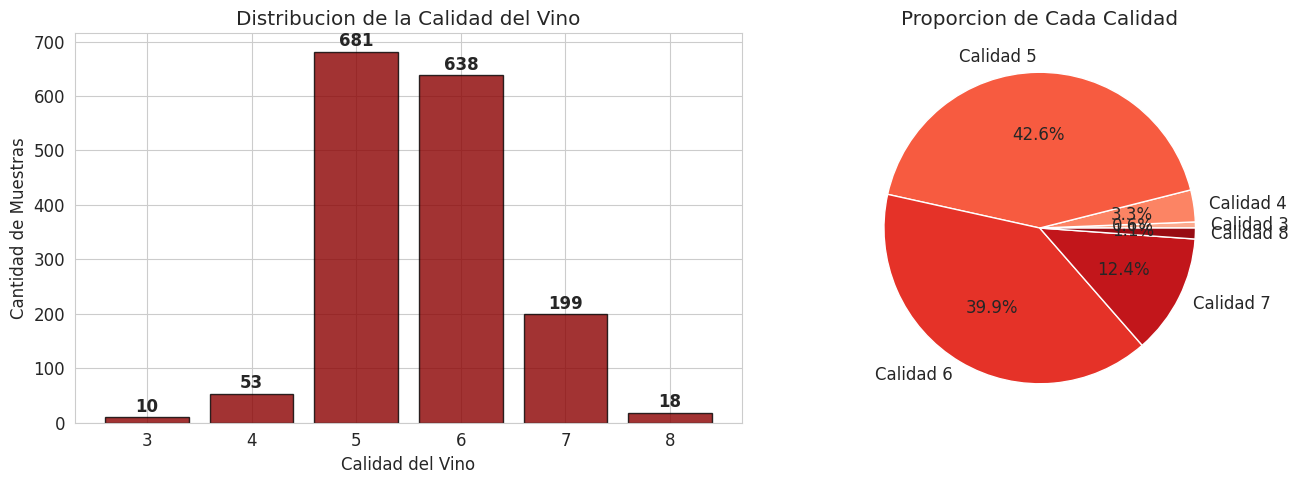


Observaciones:
- La mayoria de los vinos tienen calidad 5 o 6 (categorias intermedias).
- Hay muy pocos vinos de calidad 3 (malos) o 8 (excelentes).
- El dataset esta DESBALANCEADO: las clases extremas tienen pocas muestras.


In [7]:
# ============================================================
# Distribucion de la variable objetivo (quality)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de barras con conteo
conteo = df['quality'].value_counts().sort_index()
axes[0].bar(conteo.index, conteo.values, color='darkred', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Calidad del Vino')
axes[0].set_ylabel('Cantidad de Muestras')
axes[0].set_title('Distribucion de la Calidad del Vino')
# Agregar etiquetas sobre las barras
for i, v in enumerate(conteo.values):
    axes[0].text(conteo.index[i], v + 10, str(v), ha='center', fontweight='bold')

# Grafico de pastel con porcentajes
axes[1].pie(conteo.values, labels=[f'Calidad {i}' for i in conteo.index],
            autopct='%1.1f%%', colors=plt.cm.Reds(np.linspace(0.3, 0.9, len(conteo))))
axes[1].set_title('Proporcion de Cada Calidad')

plt.tight_layout()
plt.show()

print("\nObservaciones:")
print("- La mayoria de los vinos tienen calidad 5 o 6 (categorias intermedias).")
print("- Hay muy pocos vinos de calidad 3 (malos) o 8 (excelentes).")
print("- El dataset esta DESBALANCEADO: las clases extremas tienen pocas muestras.")

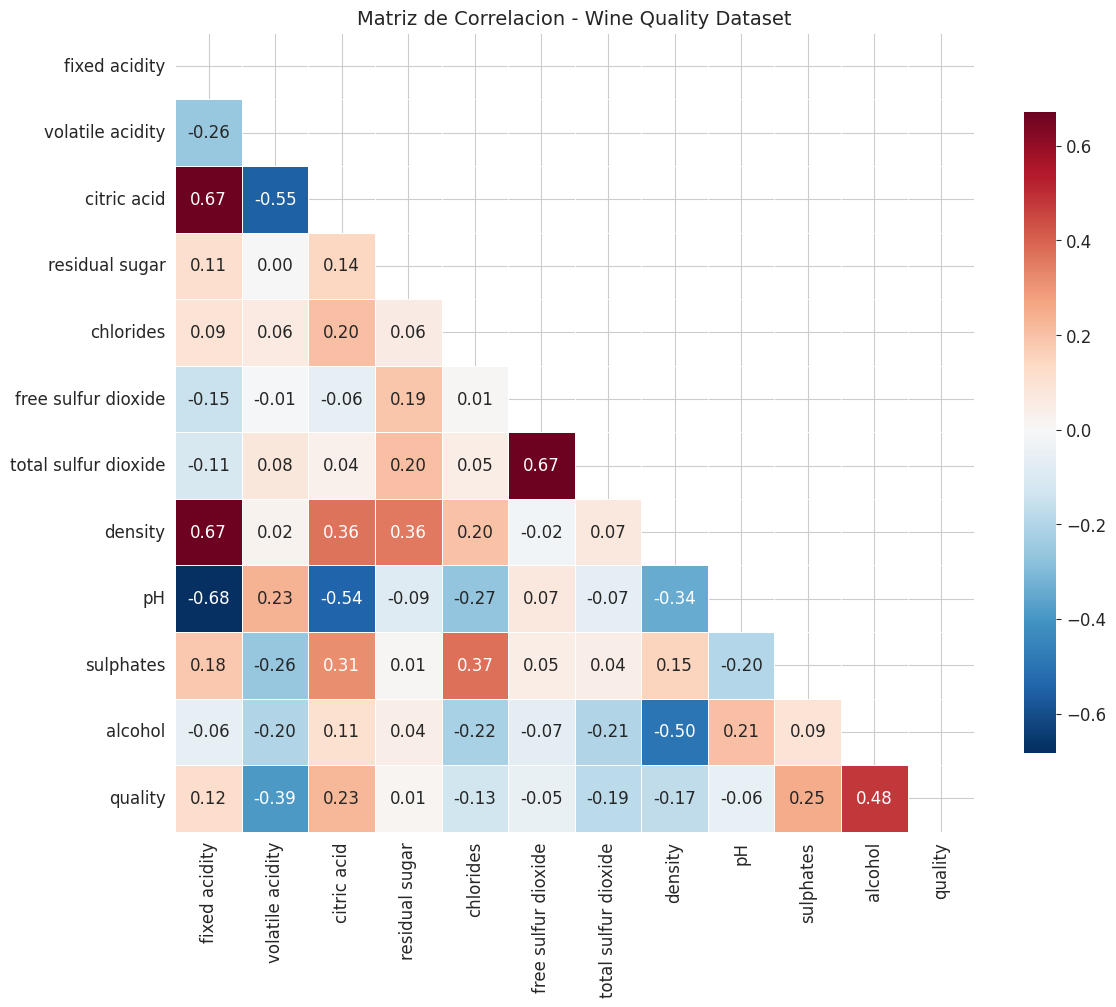


Correlacion de cada feature con 'quality':
                    alcohol: +0.476
                  sulphates: +0.251
                citric acid: +0.226
              fixed acidity: +0.124
             residual sugar: +0.014
        free sulfur dioxide: -0.051
                         pH: -0.058
                  chlorides: -0.129
                    density: -0.175
       total sulfur dioxide: -0.185
           volatile acidity: -0.391


In [8]:
# ============================================================
# Mapa de calor de correlaciones
# ============================================================
plt.figure(figsize=(12, 10))
correlacion = df.corr()
mascara = np.triu(np.ones_like(correlacion, dtype=bool))  # Mascara triangular superior

sns.heatmap(correlacion, mask=mascara, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlacion - Wine Quality Dataset', fontsize=14)
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo
print("\nCorrelacion de cada feature con 'quality':")
print("=" * 45)
corr_quality = correlacion['quality'].drop('quality').sort_values(ascending=False)
for feature, corr in corr_quality.items():
    signo = "+" if corr > 0 else ""
    print(f"  {feature:>25s}: {signo}{corr:.3f}")

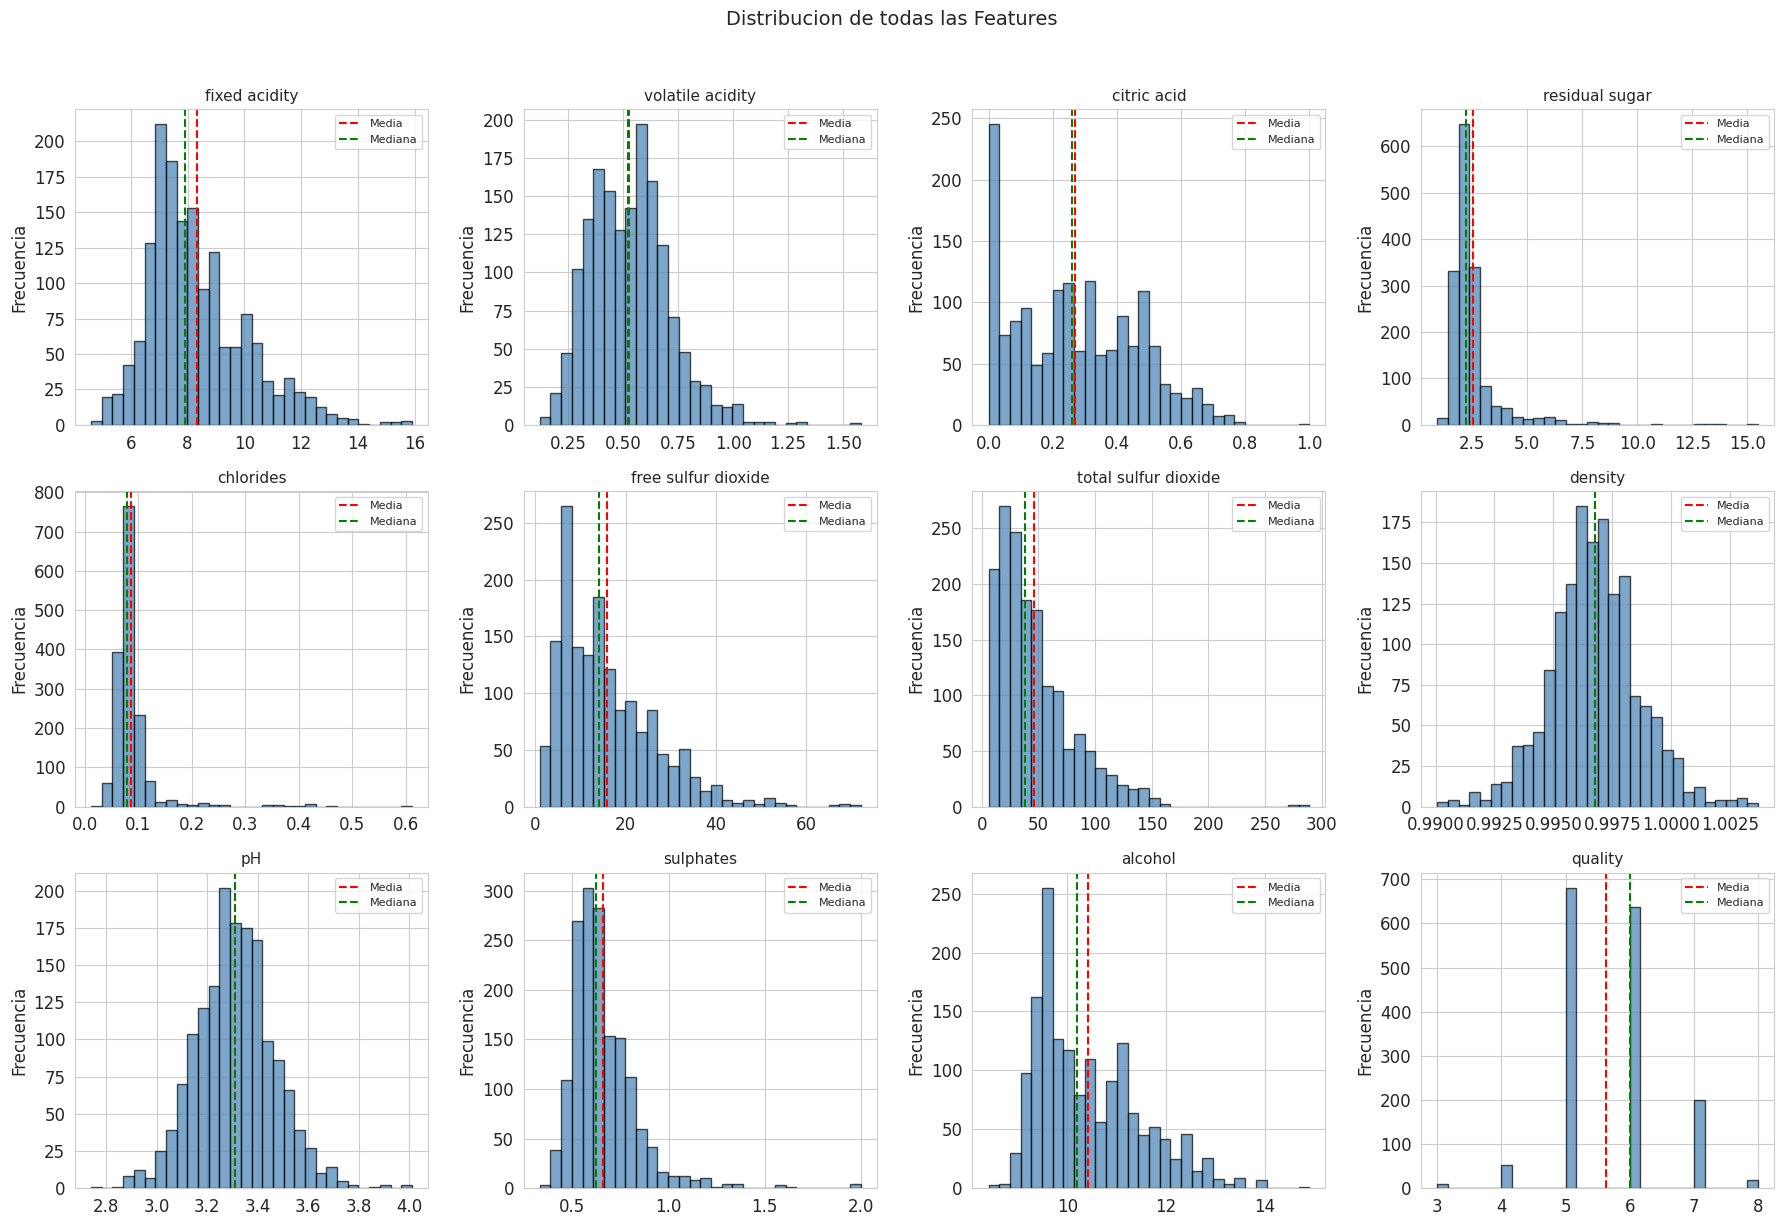


Observaciones:
- Varias features tienen distribuciones sesgadas (residual sugar, chlorides, sulphates).
- Hay outliers evidentes en varias columnas.
- Las escalas son MUY diferentes entre features (pH ~3, total sulfur dioxide ~100).
- Esto confirma la necesidad de estandarizacion.


In [9]:
# ============================================================
# Histogramas de todas las features
# ============================================================
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Frecuencia')
    # Agregar lineas de media y mediana
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Media')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label='Mediana')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribucion de todas las Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nObservaciones:")
print("- Varias features tienen distribuciones sesgadas (residual sugar, chlorides, sulphates).")
print("- Hay outliers evidentes en varias columnas.")
print("- Las escalas son MUY diferentes entre features (pH ~3, total sulfur dioxide ~100).")
print("- Esto confirma la necesidad de estandarizacion.")

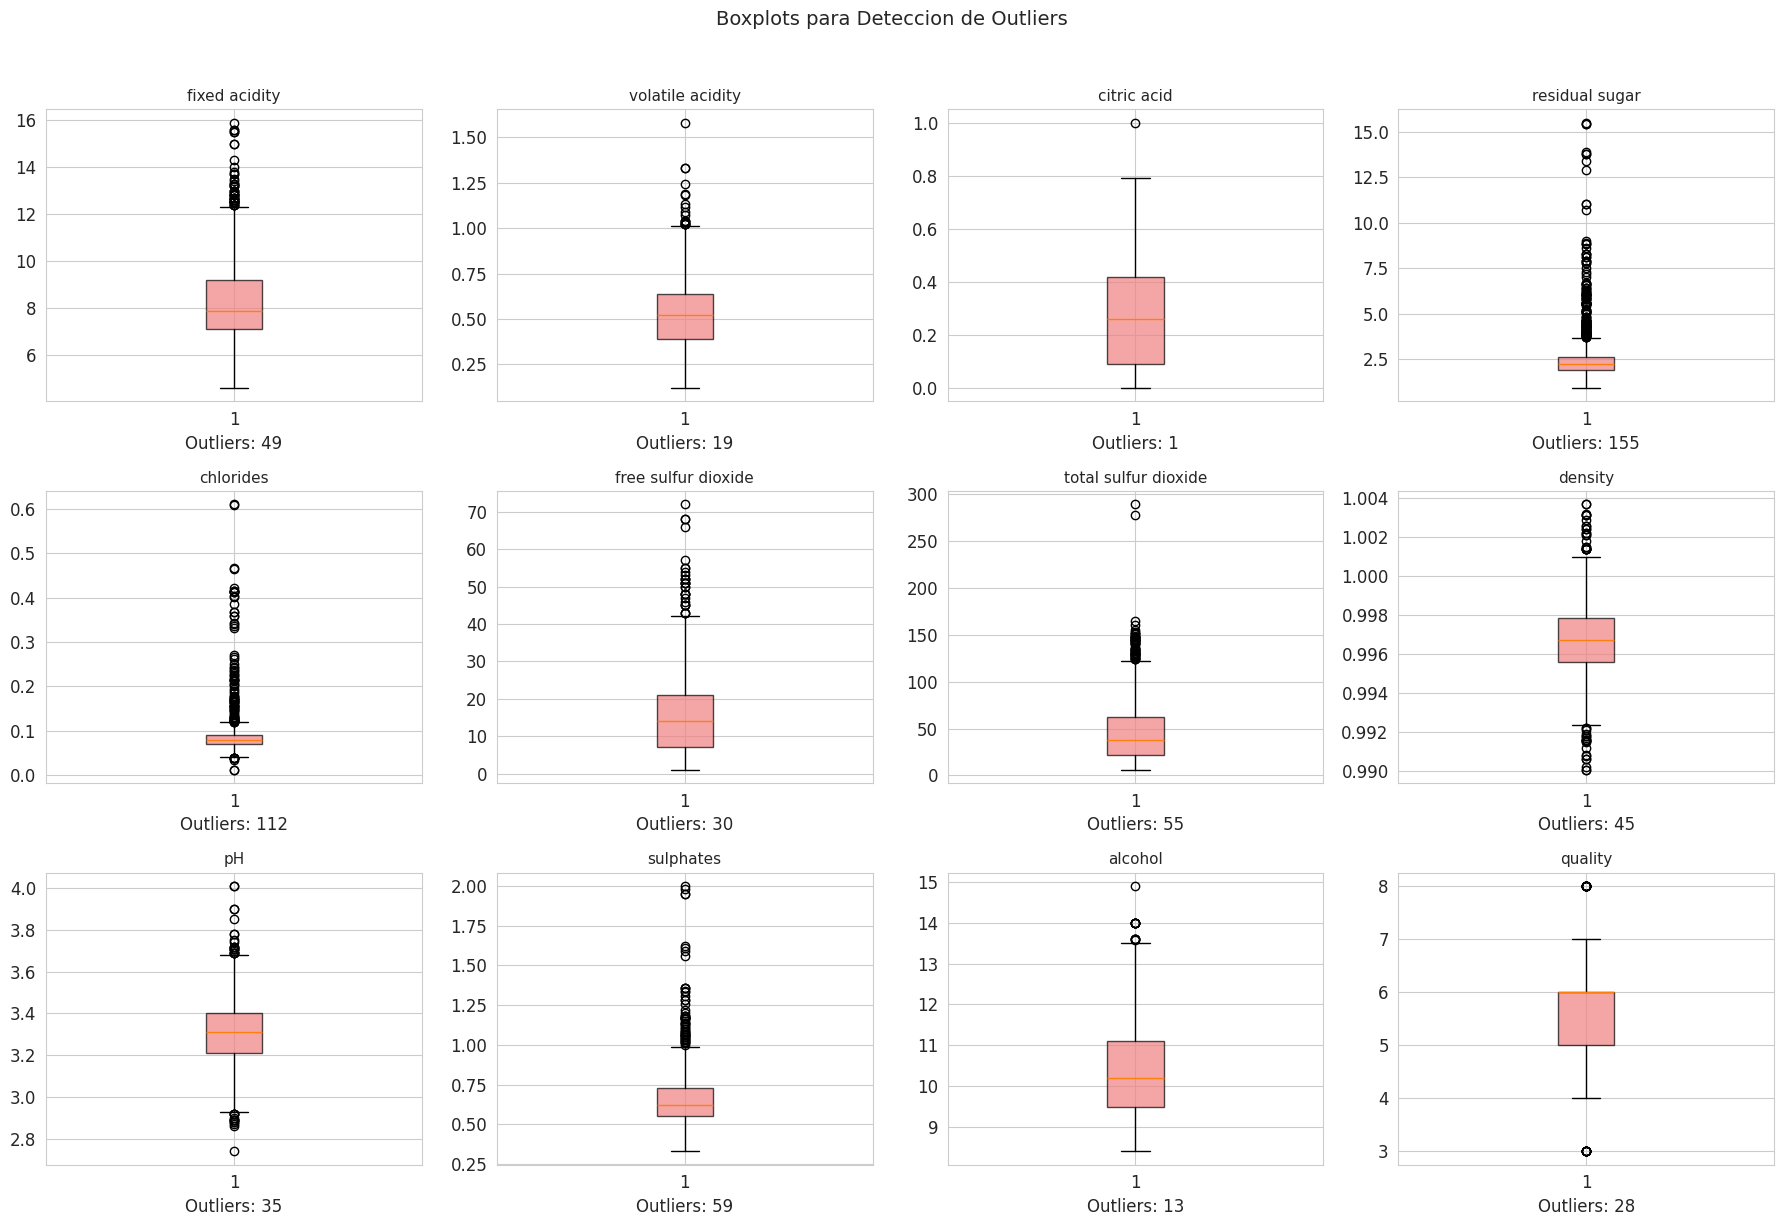

In [10]:
# ============================================================
# Deteccion de outliers con boxplots
# ============================================================
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', alpha=0.7))
    axes[i].set_title(col, fontsize=11)
    # Contar outliers usando IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    axes[i].set_xlabel(f'Outliers: {outliers}')

plt.suptitle('Boxplots para Deteccion de Outliers', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Experimentacion Guiada

### Experimento 1: Preprocesamiento de Datos

El preprocesamiento es el paso mas critico cuando trabajamos con datos tabulares. Vamos a:
1. Separar features y variable objetivo
2. Analizar si las features necesitan normalizacion
3. Aplicar `StandardScaler` y comparar distribuciones
4. Dividir los datos en train/validation/test

In [11]:
# ============================================================
# EXPERIMENTO 1: Preprocesamiento de datos
# ============================================================

# Paso 1: Separar features (X) y variable objetivo (y)
X = df.drop('quality', axis=1)  # Todas las columnas excepto 'quality'
y = df['quality']                # Solo la columna 'quality'

print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target):   {y.shape}")
print(f"\nFeatures: {list(X.columns)}")
print(f"\nRango de la variable objetivo: {y.min()} a {y.max()}")

Shape de X (features): (1599, 11)
Shape de y (target):   (1599,)

Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Rango de la variable objetivo: 3 a 8


In [12]:
# Paso 2: Analizar si necesitan normalizacion
# Veamos la escala de cada feature
print("Rango de cada feature (min -> max):")
print("=" * 55)
for col in X.columns:
    rango = X[col].max() - X[col].min()
    print(f"  {col:>25s}: [{X[col].min():8.3f} -> {X[col].max():8.3f}]  rango = {rango:.3f}")

print("\n** Las escalas son MUY diferentes.")
print("** 'total sulfur dioxide' tiene rango ~278, mientras 'density' tiene rango ~0.01")
print("** CONCLUSION: Definitivamente necesitamos estandarizar.")

Rango de cada feature (min -> max):
              fixed acidity: [   4.600 ->   15.900]  rango = 11.300
           volatile acidity: [   0.120 ->    1.580]  rango = 1.460
                citric acid: [   0.000 ->    1.000]  rango = 1.000
             residual sugar: [   0.900 ->   15.500]  rango = 14.600
                  chlorides: [   0.012 ->    0.611]  rango = 0.599
        free sulfur dioxide: [   1.000 ->   72.000]  rango = 71.000
       total sulfur dioxide: [   6.000 ->  289.000]  rango = 283.000
                    density: [   0.990 ->    1.004]  rango = 0.014
                         pH: [   2.740 ->    4.010]  rango = 1.270
                  sulphates: [   0.330 ->    2.000]  rango = 1.670
                    alcohol: [   8.400 ->   14.900]  rango = 6.500

** Las escalas son MUY diferentes.
** 'total sulfur dioxide' tiene rango ~278, mientras 'density' tiene rango ~0.01
** CONCLUSION: Definitivamente necesitamos estandarizar.


In [13]:
# Paso 3: Dividir en train/validation/test ANTES de estandarizar
# Esto es CRITICO: nunca ajustar el scaler con datos de test

# Primero: 80% train_temp, 20% test
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

# Segundo: del 80% anterior, 75% train (60% total), 25% val (20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.25, random_state=SEED
)

print("Division de datos (60/20/20):")
print(f"  Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Validacion:    {X_val.shape[0]} muestras ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"  Test:          {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.0f}%)")

Division de datos (60/20/20):
  Entrenamiento: 959 muestras (60%)
  Validacion:    320 muestras (20%)
  Test:          320 muestras (20%)


In [14]:
# Paso 4: Aplicar StandardScaler
# IMPORTANTE: fit SOLO con datos de entrenamiento

scaler = StandardScaler()

# Ajustar y transformar los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform

# Solo transformar validacion y test (NO hacer fit)
X_val_scaled = scaler.transform(X_val)       # Solo transform
X_test_scaled = scaler.transform(X_test)     # Solo transform

# Convertir a DataFrame para visualizar
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("Datos despues de estandarizar (entrenamiento):")
print(X_train_scaled_df.describe().round(3))
print("\nObserva: la media es ~0 y la desviacion estandar es ~1 para todas las features.")

Datos despues de estandarizar (entrenamiento):
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count        959.000           959.000      959.000         959.000   
mean           0.000             0.000       -0.000          -0.000   
std            1.001             1.001        1.001           1.001   
min           -2.110            -2.277       -1.394          -1.161   
25%           -0.716            -0.724       -0.886          -0.452   
50%           -0.251            -0.058       -0.073          -0.239   
75%            0.503             0.552        0.842           0.045   
max            4.220             5.821        3.687           9.199   

       chlorides  free sulfur dioxide  total sulfur dioxide  density       pH  \
count    959.000              959.000               959.000  959.000  959.000   
mean       0.000               -0.000                -0.000   -0.000   -0.000   
std        1.001                1.001                 1.001    1.001  

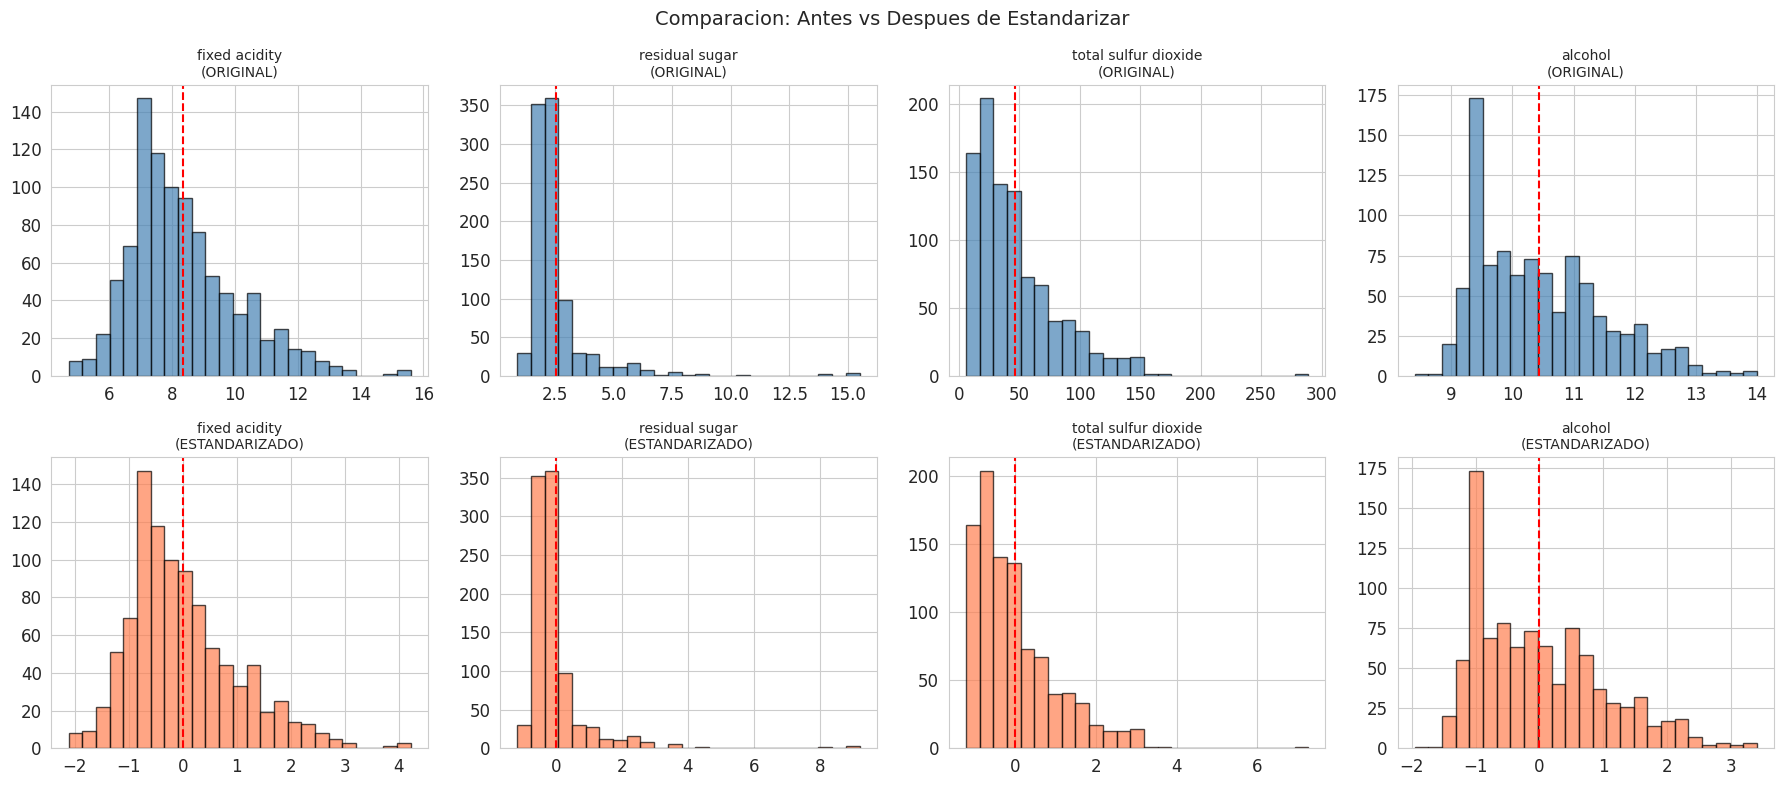

Observa como despues de estandarizar:
- Todas las features estan centradas alrededor de 0
- Todas tienen una escala similar
- La FORMA de la distribucion NO cambia (solo la escala)


In [15]:
# Paso 5: Comparar distribuciones antes y despues de estandarizar
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# Seleccionar 4 features representativas
features_ejemplo = ['fixed acidity', 'residual sugar', 'total sulfur dioxide', 'alcohol']

for i, col in enumerate(features_ejemplo):
    col_idx = list(X.columns).index(col)

    # Antes de estandarizar
    axes[0, i].hist(X_train[col], bins=25, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{col}\n(ORIGINAL)', fontsize=10)
    axes[0, i].axvline(X_train[col].mean(), color='red', linestyle='--')

    # Despues de estandarizar
    axes[1, i].hist(X_train_scaled[:, col_idx], bins=25, color='coral', edgecolor='black', alpha=0.7)
    axes[1, i].set_title(f'{col}\n(ESTANDARIZADO)', fontsize=10)
    axes[1, i].axvline(X_train_scaled[:, col_idx].mean(), color='red', linestyle='--')

plt.suptitle('Comparacion: Antes vs Despues de Estandarizar', fontsize=14)
plt.tight_layout()
plt.show()

print("Observa como despues de estandarizar:")
print("- Todas las features estan centradas alrededor de 0")
print("- Todas tienen una escala similar")
print("- La FORMA de la distribucion NO cambia (solo la escala)")

### \u270d\ufe0f Pregunta - Experimento 1

**\u00bfPor que es importante normalizar (o estandarizar) los datos antes de entrenarlos en una red neuronal? \u00bfQue pasaria si no lo hicieramos?**

*Pista: Piensa en como el gradiente descendente actualiza los pesos y que pasa cuando las features tienen escalas muy diferentes.*

### \u270d\ufe0f Tu respuesta:

*Escribe aqui tu respuesta...*

---
### Experimento 2: DNN para Regresion

Vamos a predecir la calidad del vino como un **valor continuo** (regresion). Esto significa que nuestra red predecira un numero real (ej: 5.3, 6.7) en lugar de una categoria.

**Arquitectura:** Entrada (11 features) -> 128 -> 64 -> 32 -> 1 (sin activacion)

In [16]:
# ============================================================
# EXPERIMENTO 2: DNN para Regresion
# ============================================================

def crear_modelo_regresion(nombre='modelo_regresion'):
    """
    Crea una DNN para regresion.
    Arquitectura: 11 -> 128 -> 64 -> 32 -> 1
    """
    modelo = keras.Sequential([
        # Capa de entrada: especificamos la dimension del input
        layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],),
                     name='capa_oculta_1'),
        layers.BatchNormalization(name='bn_1'),
        layers.Dropout(0.3, name='dropout_1'),

        # Segunda capa oculta
        layers.Dense(64, activation='relu', name='capa_oculta_2'),
        layers.BatchNormalization(name='bn_2'),
        layers.Dropout(0.2, name='dropout_2'),

        # Tercera capa oculta
        layers.Dense(32, activation='relu', name='capa_oculta_3'),

        # Capa de salida para REGRESION:
        # - 1 sola neurona (predecimos un unico valor)
        # - SIN funcion de activacion (la salida puede ser cualquier numero real)
        layers.Dense(1, name='salida_regresion')  # Sin activacion!
    ], name=nombre)

    return modelo

# Crear el modelo
modelo_reg = crear_modelo_regresion()

# Compilar con MSE como funcion de perdida y MAE como metrica adicional
modelo_reg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',          # Mean Squared Error como perdida
    metrics=['mae']      # Mean Absolute Error como metrica
)

# Resumen del modelo
modelo_reg.summary()

Model: "modelo_regresion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_oculta_1 (Dense)           │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_2 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ capa_oculta_3 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_regresion (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [17]:
# Entrenar el modelo
print("Entrenando DNN para regresion...")
print("=" * 50)

historia_reg = modelo_reg.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    ]
)

print("\nEntrenamiento completado.")

Entrenando DNN para regresion...
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - loss: 25.5475 - mae: 4.8800 - val_loss: 24.7565 - val_mae: 4.9044
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.1031 - mae: 2.8819 - val_loss: 16.2447 - val_mae: 3.9405
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2674 - mae: 1.5050 - val_loss: 9.6304 - val_mae: 2.9892
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8596 - mae: 1.0705 - val_loss: 5.8189 - val_mae: 2.2611
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.4016 - mae: 0.9536 - val_loss: 3.7625 - val_mae: 1.7628
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1805 - mae: 0.8690 - val_loss: 2.4636 - val_mae: 1.3553
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1260 - mae: 0.8460 - val_loss: 1.6924 - val_mae: 1.0791
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0221 - mae: 0.8120 - val_loss: 1.1659 - val_mae: 0.8586
Epoch 9/100
30/30 ━━━━━━━━

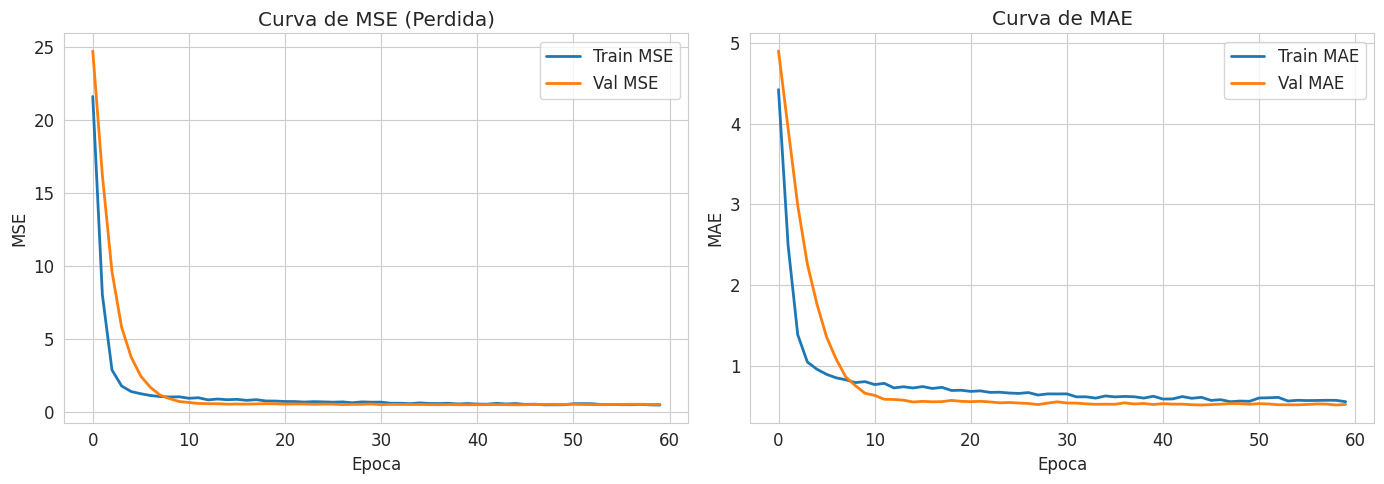


Resultados en TEST:
  MSE: 0.3902
  MAE: 0.4999
  RMSE: 0.6246
  R2 Score: 0.4029

Interpretacion del MAE: en promedio, la prediccion se equivoca por 0.50 puntos de calidad.


In [18]:
# Graficar curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de MSE (Loss)
axes[0].plot(historia_reg.history['loss'], label='Train MSE', linewidth=2)
axes[0].plot(historia_reg.history['val_loss'], label='Val MSE', linewidth=2)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('MSE')
axes[0].set_title('Curva de MSE (Perdida)')
axes[0].legend()
axes[0].grid(True)

# Curva de MAE
axes[1].plot(historia_reg.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(historia_reg.history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('MAE')
axes[1].set_title('Curva de MAE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluar en test
test_mse, test_mae = modelo_reg.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nResultados en TEST:")
print(f"  MSE: {test_mse:.4f}")
print(f"  MAE: {test_mae:.4f}")
print(f"  RMSE: {np.sqrt(test_mse):.4f}")

# R2 Score
y_pred_reg = modelo_reg.predict(X_test_scaled, verbose=0).flatten()
r2 = r2_score(y_test, y_pred_reg)
print(f"  R2 Score: {r2:.4f}")
print(f"\nInterpretacion del MAE: en promedio, la prediccion se equivoca por {test_mae:.2f} puntos de calidad.")

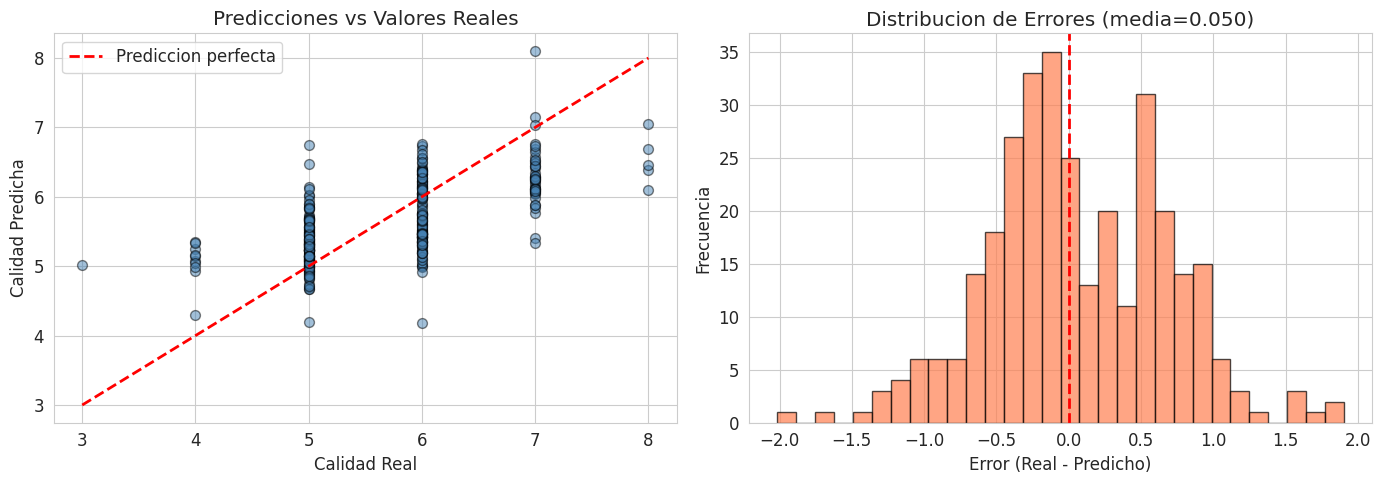

In [19]:
# Visualizar predicciones vs valores reales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot de predicciones vs reales
axes[0].scatter(y_test, y_pred_reg, alpha=0.5, color='steelblue', edgecolors='black', s=50)
axes[0].plot([3, 8], [3, 8], 'r--', linewidth=2, label='Prediccion perfecta')
axes[0].set_xlabel('Calidad Real')
axes[0].set_ylabel('Calidad Predicha')
axes[0].set_title('Predicciones vs Valores Reales')
axes[0].legend()
axes[0].grid(True)

# Distribucion de errores
errores = y_test.values - y_pred_reg
axes[1].hist(errores, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Error (Real - Predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribucion de Errores (media={errores.mean():.3f})')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### \u270d\ufe0f Pregunta - Experimento 2

**\u00bfQue significan MAE y MSE intuitivamente? \u00bfCual es mas sensible a errores grandes? \u00bfPor que usamos MSE como loss y MAE como metrica?**

*Pista: Si un modelo predice calidad 5 cuando la real es 8, \u00bfcuanto contribuye ese error al MAE vs al MSE?*

### \u270d\ufe0f Tu respuesta:

*Escribe aqui tu respuesta...*

---
### Experimento 3: Red Ancha vs Red Profunda

Una pregunta fundamental en el diseno de redes neuronales es: **\u00bfes mejor tener pocas capas con muchas neuronas (red ancha) o muchas capas con pocas neuronas (red profunda)?**

Vamos a comparar tres arquitecturas:
- **Red ancha:** 1 capa de 512 neuronas
- **Red profunda:** 4 capas de 64 neuronas cada una
- **Red mixta:** 2 capas de 256 y 128 neuronas

In [20]:
# ============================================================
# EXPERIMENTO 3: Red Ancha vs Red Profunda
# ============================================================

def crear_red_ancha():
    """Red ancha: 1 capa con 512 neuronas"""
    modelo = keras.Sequential([
        layers.Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dropout(0.3),
        layers.Dense(1)
    ], name='red_ancha')
    return modelo

def crear_red_profunda():
    """Red profunda: 4 capas con 64 neuronas cada una"""
    modelo = keras.Sequential([
        layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ], name='red_profunda')
    return modelo

def crear_red_mixta():
    """Red mixta: 2 capas con 256 y 128 neuronas"""
    modelo = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ], name='red_mixta')
    return modelo

# Crear y compilar los tres modelos
modelos = {
    'Red Ancha (1x512)': crear_red_ancha(),
    'Red Profunda (4x64)': crear_red_profunda(),
    'Red Mixta (256+128)': crear_red_mixta()
}

for nombre, modelo in modelos.items():
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

# Mostrar numero de parametros de cada modelo
print("Comparacion de arquitecturas:")
print("=" * 55)
for nombre, modelo in modelos.items():
    n_params = modelo.count_params()
    print(f"  {nombre:25s}: {n_params:>8,} parametros")

Comparacion de arquitecturas:
  Red Ancha (1x512)        :    6,657 parametros
  Red Profunda (4x64)      :   13,313 parametros
  Red Mixta (256+128)      :   36,097 parametros


In [21]:
# Entrenar los tres modelos
historias = {}
resultados = {}

for nombre, modelo in modelos.items():
    print(f"\nEntrenando: {nombre}")
    print("-" * 40)

    historia = modelo.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=32,
        verbose=0,
        callbacks=[
            callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
        ]
    )

    historias[nombre] = historia

    # Evaluar en test
    test_mse, test_mae = modelo.evaluate(X_test_scaled, y_test, verbose=0)
    y_pred = modelo.predict(X_test_scaled, verbose=0).flatten()
    r2 = r2_score(y_test, y_pred)

    resultados[nombre] = {
        'MSE': test_mse,
        'MAE': test_mae,
        'RMSE': np.sqrt(test_mse),
        'R2': r2,
        'Epocas': len(historia.history['loss']),
        'Parametros': modelo.count_params()
    }

    print(f"  MSE: {test_mse:.4f} | MAE: {test_mae:.4f} | R2: {r2:.4f} | Epocas: {len(historia.history['loss'])}")

print("\nEntrenamiento de los tres modelos completado.")


Entrenando: Red Ancha (1x512)
----------------------------------------
  MSE: 0.3470 | MAE: 0.4675 | R2: 0.4691 | Epocas: 85

Entrenando: Red Profunda (4x64)
----------------------------------------
  MSE: 0.3866 | MAE: 0.4931 | R2: 0.4084 | Epocas: 65

Entrenando: Red Mixta (256+128)
----------------------------------------
  MSE: 0.3596 | MAE: 0.4755 | R2: 0.4497 | Epocas: 83

Entrenamiento de los tres modelos completado.


In [22]:
# Tabla comparativa de resultados
df_resultados = pd.DataFrame(resultados).T
print("\nTabla Comparativa de Resultados:")
print("=" * 70)
print(df_resultados.round(4).to_string())


Tabla Comparativa de Resultados:
                        MSE     MAE    RMSE      R2  Epocas  Parametros
Red Ancha (1x512)    0.3470  0.4675  0.5890  0.4691    85.0      6657.0
Red Profunda (4x64)  0.3866  0.4931  0.6218  0.4084    65.0     13313.0
Red Mixta (256+128)  0.3596  0.4755  0.5997  0.4497    83.0     36097.0


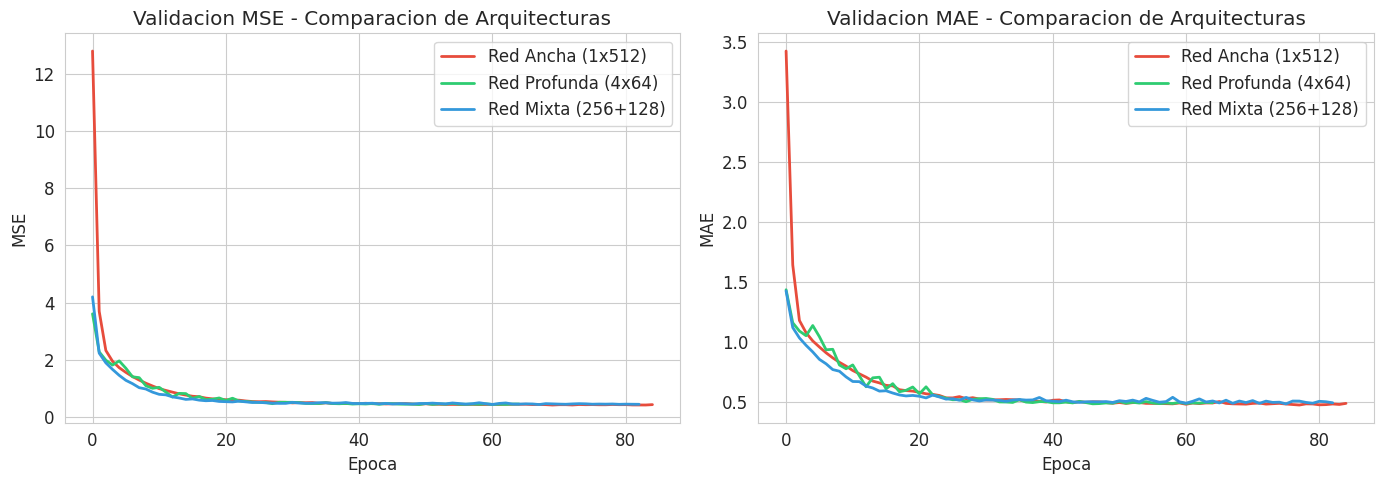

In [23]:
# Graficar comparacion de curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = ['#e74c3c', '#2ecc71', '#3498db']

for i, (nombre, historia) in enumerate(historias.items()):
    # Curva de MSE
    axes[0].plot(historia.history['val_loss'], label=nombre, linewidth=2, color=colores[i])
    # Curva de MAE
    axes[1].plot(historia.history['val_mae'], label=nombre, linewidth=2, color=colores[i])

axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('MSE')
axes[0].set_title('Validacion MSE - Comparacion de Arquitecturas')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('MAE')
axes[1].set_title('Validacion MAE - Comparacion de Arquitecturas')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

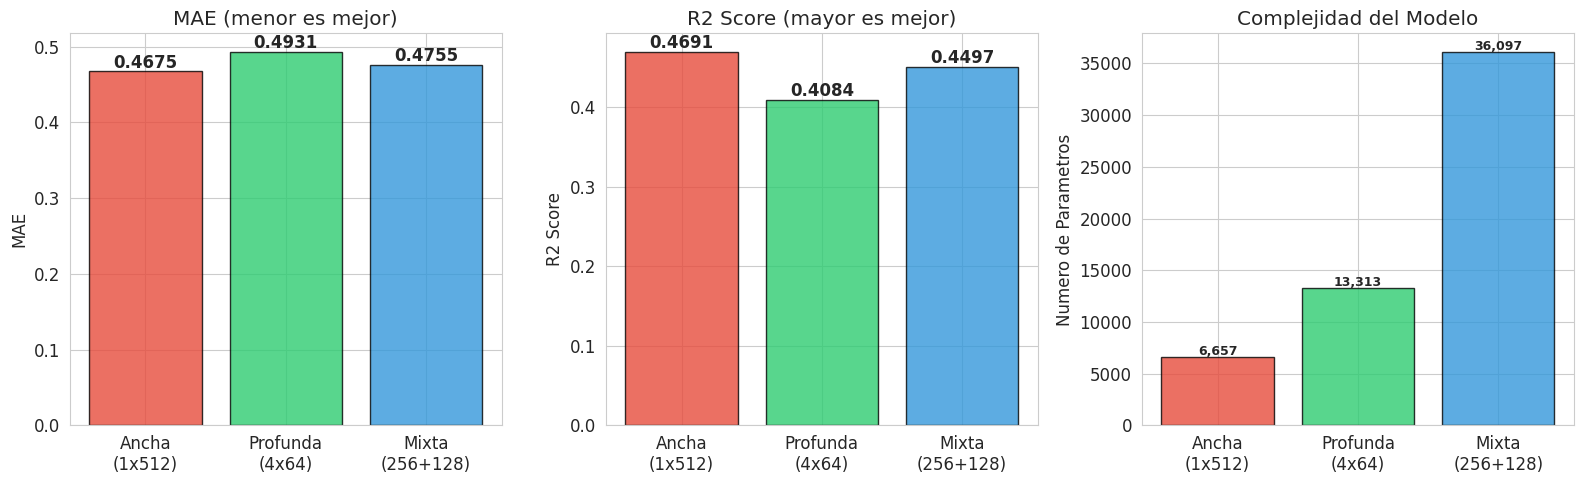

In [24]:
# Grafico de barras comparativo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

nombres = list(resultados.keys())
nombres_cortos = ['Ancha\n(1x512)', 'Profunda\n(4x64)', 'Mixta\n(256+128)']

# MAE
maes = [resultados[n]['MAE'] for n in nombres]
bars = axes[0].bar(nombres_cortos, maes, color=colores, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE (menor es mejor)')
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontweight='bold')

# R2
r2s = [resultados[n]['R2'] for n in nombres]
bars = axes[1].bar(nombres_cortos, r2s, color=colores, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('R2 Score')
axes[1].set_title('R2 Score (mayor es mejor)')
for bar, val in zip(bars, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontweight='bold')

# Parametros
params = [resultados[n]['Parametros'] for n in nombres]
bars = axes[2].bar(nombres_cortos, params, color=colores, edgecolor='black', alpha=0.8)
axes[2].set_ylabel('Numero de Parametros')
axes[2].set_title('Complejidad del Modelo')
for bar, val in zip(bars, params):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### \u270d\ufe0f Pregunta - Experimento 3

**\u00bfCual arquitectura funciono mejor? \u00bfMas profunda o mas ancha? \u00bfCoincide con tu intuicion? Considera tambien el numero de parametros en tu analisis: \u00bfmas parametros siempre significa mejor rendimiento?**

### \u270d\ufe0f Tu respuesta:

*Escribe aqui tu respuesta...*

---
### Experimento 4: Callbacks Avanzados

En un proyecto real, no basta con `model.fit()`. Necesitamos herramientas para:
- **Guardar el mejor modelo** automaticamente durante el entrenamiento
- **Reducir el learning rate** cuando el modelo deja de mejorar
- **Registrar todo** en un archivo para analisis posterior
- **Detener el entrenamiento** si no hay progreso

Vamos a usar los 4 callbacks avanzados juntos.

In [25]:
# ============================================================
# EXPERIMENTO 4: Callbacks Avanzados
# ============================================================

# Crear directorios para guardar archivos
os.makedirs('modelos', exist_ok=True)
os.makedirs('logs', exist_ok=True)

# Crear un modelo nuevo para este experimento
modelo_callbacks = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
], name='modelo_con_callbacks')

modelo_callbacks.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),  # LR alto a proposito
    loss='mse',
    metrics=['mae']
)

print("Modelo creado con learning rate ALTO (0.01) para ver el efecto de ReduceLROnPlateau.")

Modelo creado con learning rate ALTO (0.01) para ver el efecto de ReduceLROnPlateau.


In [26]:
# Definir los callbacks avanzados

# 1. ModelCheckpoint: guardar el mejor modelo automaticamente
checkpoint = callbacks.ModelCheckpoint(
    filepath='modelos/mejor_modelo.keras',   # Ruta donde guardar
    monitor='val_loss',                      # Metrica a monitorear
    save_best_only=True,                     # Solo guardar si mejora
    save_weights_only=False,                 # Guardar modelo completo
    verbose=1                                # Mostrar cuando guarda
)

# 2. ReduceLROnPlateau: reducir el LR cuando no hay mejora
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',        # Metrica a monitorear
    factor=0.5,                # Multiplicar LR por 0.5 (reducir a la mitad)
    patience=5,                # Epocas sin mejora antes de reducir
    min_lr=1e-7,               # LR minimo (no reducir mas alla de esto)
    verbose=1                  # Mostrar cuando reduce
)

# 3. CSVLogger: guardar historial de entrenamiento en CSV
csv_logger = callbacks.CSVLogger(
    'logs/historial_entrenamiento.csv',   # Archivo de salida
    separator=',',                         # Separador
    append=False                           # No agregar a un archivo existente
)

# 4. EarlyStopping: detener si no hay mejora
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,                # Epocas sin mejora antes de detener
    restore_best_weights=True,  # Restaurar los mejores pesos
    verbose=1
)

# Lista con todos los callbacks
lista_callbacks = [checkpoint, reduce_lr, csv_logger, early_stop]

print("Callbacks configurados:")
print("  1. ModelCheckpoint -> Guarda el mejor modelo en 'modelos/mejor_modelo.keras'")
print("  2. ReduceLROnPlateau -> Reduce LR x0.5 si val_loss no mejora en 5 epocas")
print("  3. CSVLogger -> Guarda historial en 'logs/historial_entrenamiento.csv'")
print("  4. EarlyStopping -> Detiene si val_loss no mejora en 20 epocas")

Callbacks configurados:
  1. ModelCheckpoint -> Guarda el mejor modelo en 'modelos/mejor_modelo.keras'
  2. ReduceLROnPlateau -> Reduce LR x0.5 si val_loss no mejora en 5 epocas
  3. CSVLogger -> Guarda historial en 'logs/historial_entrenamiento.csv'
  4. EarlyStopping -> Detiene si val_loss no mejora en 20 epocas


In [27]:
# Entrenar con todos los callbacks
print("Entrenando con TODOS los callbacks...")
print("=" * 60)
print("Observa los mensajes de los callbacks durante el entrenamiento.\n")

historia_callbacks = modelo_callbacks.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,     # Muchas epocas para ver los callbacks en accion
    batch_size=32,
    verbose=1,
    callbacks=lista_callbacks
)

print("\nEntrenamiento completado.")
print(f"Epocas totales: {len(historia_callbacks.history['loss'])}")

Entrenando con TODOS los callbacks...
Observa los mensajes de los callbacks durante el entrenamiento.

Epoch 1/150
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 13.3618 - mae: 2.9798
Epoch 1: val_loss improved from inf to 11.92738, saving model to modelos/mejor_modelo.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - loss: 13.1309 - mae: 2.9427 - val_loss: 11.9274 - val_mae: 3.3634 - learning_rate: 0.0100
Epoch 2/150
22/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2000 - mae: 0.8729 
Epoch 2: val_loss improved from 11.92738 to 5.28918, saving model to modelos/mejor_modelo.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1981 - mae: 0.8683 - val_loss: 5.2892 - val_mae: 2.1742 - learning_rate: 0.0100
Epoch 3/150
21/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8819 - mae: 0.7753 
Epoch 3: val_loss improved from 5.28918 to 3.19088, saving model to modelos/mejor_modelo.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8732 - mae: 0.7654 - val_loss: 3.1909 - val_mae: 1.6210 - l

In [28]:
# Verificar el historial guardado en CSV
historial_csv = pd.read_csv('logs/historial_entrenamiento.csv')
print("Historial de entrenamiento guardado en CSV:")
print(f"  Filas (epocas): {len(historial_csv)}")
print(f"  Columnas: {list(historial_csv.columns)}")
print("\nUltimas 5 epocas:")
print(historial_csv.tail())

Historial de entrenamiento guardado en CSV:
  Filas (epocas): 70
  Columnas: ['epoch', 'learning_rate', 'loss', 'mae', 'val_loss', 'val_mae']

Ultimas 5 epocas:
    epoch  learning_rate      loss       mae  val_loss   val_mae
65     65       0.000078  0.304340  0.436779  0.479444  0.510190
66     66       0.000078  0.305539  0.435299  0.479024  0.510844
67     67       0.000078  0.303721  0.434860  0.477584  0.511164
68     68       0.000078  0.284805  0.420867  0.478841  0.511842
69     69       0.000078  0.299070  0.428645  0.478456  0.510948


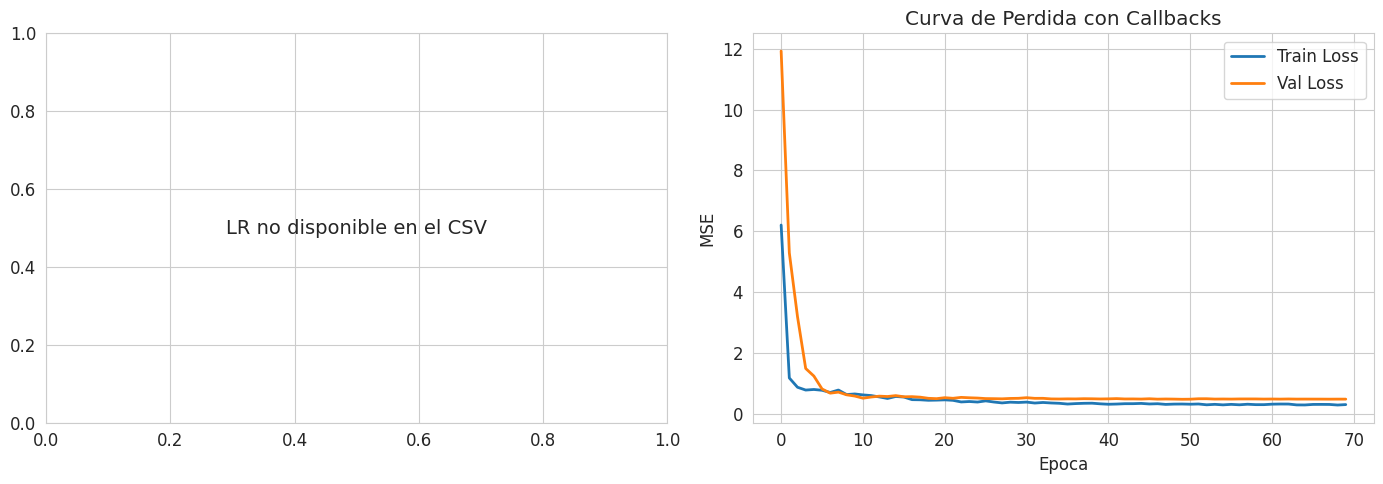


Resultados en TEST (modelo con callbacks):
  MSE: 0.3836
  MAE: 0.4821


In [29]:
# Visualizar el efecto de ReduceLROnPlateau
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de learning rate a lo largo del entrenamiento
if 'lr' in historial_csv.columns:
    axes[0].plot(historial_csv['lr'], linewidth=2, color='purple')
    axes[0].set_xlabel('Epoca')
    axes[0].set_ylabel('Learning Rate')
    axes[0].set_title('Evolucion del Learning Rate')
    axes[0].set_yscale('log')  # Escala logaritmica para ver mejor los cambios
    axes[0].grid(True)

    # Contar cuantas veces se redujo
    lr_values = historial_csv['lr'].values
    reducciones = sum(1 for i in range(1, len(lr_values)) if lr_values[i] < lr_values[i-1])
    axes[0].set_title(f'Learning Rate (se redujo {reducciones} veces)')
else:
    axes[0].text(0.5, 0.5, 'LR no disponible en el CSV', transform=axes[0].transAxes,
                 ha='center', va='center', fontsize=14)

# Curva de perdida
axes[1].plot(historial_csv['loss'], label='Train Loss', linewidth=2)
axes[1].plot(historial_csv['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('MSE')
axes[1].set_title('Curva de Perdida con Callbacks')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluar el modelo entrenado con callbacks
test_mse_cb, test_mae_cb = modelo_callbacks.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nResultados en TEST (modelo con callbacks):")
print(f"  MSE: {test_mse_cb:.4f}")
print(f"  MAE: {test_mae_cb:.4f}")

### \u270d\ufe0f Pregunta - Experimento 4

**\u00bfCuantas veces se redujo el learning rate durante el entrenamiento? \u00bfEn que epoca se guardo el mejor modelo? \u00bfQue efecto tuvo la reduccion del LR en la curva de perdida?**

*Pista: Observa los mensajes de los callbacks y el grafico del learning rate.*

### \u270d\ufe0f Tu respuesta:

*Escribe aqui tu respuesta...*

---
### Experimento 5: Guardar y Cargar Modelos

En un proyecto real, necesitamos guardar nuestro modelo entrenado para usarlo despues sin tener que reentrenarlo. Keras ofrece varias formas de hacerlo:

1. **Modelo completo** (`.keras` o `.h5`): Guarda arquitectura + pesos + optimizador
2. **Solo pesos** (`.weights.h5`): Solo los valores de los parametros
3. **Arquitectura en JSON**: Solo la estructura de la red (sin pesos)

In [30]:
# ============================================================
# EXPERIMENTO 5: Guardar y Cargar Modelos
# ============================================================

# Usar el modelo con callbacks que ya entrenamos
print("=" * 60)
print("METODO 1: Guardar modelo COMPLETO (.keras)")
print("=" * 60)

# Guardar modelo completo en formato Keras nativo
modelo_callbacks.save('modelos/modelo_completo.keras')
print("Modelo completo guardado en 'modelos/modelo_completo.keras'")

# Verificar el tamano del archivo
tamano_keras = os.path.getsize('modelos/modelo_completo.keras') / 1024
print(f"Tamano del archivo: {tamano_keras:.1f} KB")

print("\nEste archivo contiene:")
print("  - La arquitectura completa de la red")
print("  - Todos los pesos entrenados")
print("  - La configuracion del optimizador")
print("  - Se puede cargar y usar directamente para predecir")

METODO 1: Guardar modelo COMPLETO (.keras)
Modelo completo guardado en 'modelos/modelo_completo.keras'
Tamano del archivo: 190.9 KB

Este archivo contiene:
  - La arquitectura completa de la red
  - Todos los pesos entrenados
  - La configuracion del optimizador
  - Se puede cargar y usar directamente para predecir


In [31]:
print("=" * 60)
print("METODO 2: Guardar SOLO los pesos")
print("=" * 60)

# Guardar solo los pesos
modelo_callbacks.save_weights('modelos/solo_pesos.weights.h5')
print("Pesos guardados en 'modelos/solo_pesos.weights.h5'")

# Verificar tamano
tamano_pesos = os.path.getsize('modelos/solo_pesos.weights.h5') / 1024
print(f"Tamano del archivo: {tamano_pesos:.1f} KB")

print("\nEste archivo contiene:")
print("  - SOLO los valores de los pesos")
print("  - NO incluye la arquitectura ni el optimizador")
print("  - Para usarlo, necesitas recrear la arquitectura primero")

METODO 2: Guardar SOLO los pesos
Pesos guardados en 'modelos/solo_pesos.weights.h5'
Tamano del archivo: 184.0 KB

Este archivo contiene:
  - SOLO los valores de los pesos
  - NO incluye la arquitectura ni el optimizador
  - Para usarlo, necesitas recrear la arquitectura primero


In [32]:
print("=" * 60)
print("METODO 3: Guardar ARQUITECTURA en JSON")
print("=" * 60)

# Guardar la arquitectura como JSON
arquitectura_json = modelo_callbacks.to_json()

# Guardar el JSON en un archivo
with open('modelos/arquitectura.json', 'w') as f:
    json.dump(json.loads(arquitectura_json), f, indent=2)

print("Arquitectura guardada en 'modelos/arquitectura.json'")
print(f"\nContenido del JSON (primeros 500 caracteres):")
print(arquitectura_json[:500] + '...')

print("\nEste archivo contiene:")
print("  - SOLO la estructura de la red (capas, activaciones, etc.)")
print("  - NO incluye pesos ni optimizador")
print("  - Util para documentar o compartir la arquitectura")

METODO 3: Guardar ARQUITECTURA en JSON
Arquitectura guardada en 'modelos/arquitectura.json'

Contenido del JSON (primeros 500 caracteres):
{"module": "keras", "class_name": "Sequential", "config": {"name": "modelo_con_callbacks", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 11], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_layer_4"}, "registered_name": null}, {"module": "keras.layers", "class_name": "Dense", "config": {"nam...

Este archivo contiene:
  - SOLO la estructura de la red (capas, activaciones, etc.)
  - NO incluye pesos ni optimizador
  - Util para documentar o compartir la arquitectura


In [33]:
print("=" * 60)
print("CARGAR MODELOS Y VERIFICAR")
print("=" * 60)

# ---- Metodo 1: Cargar modelo completo ----
print("\n--- Cargando modelo completo ---")
modelo_cargado = keras.models.load_model('modelos/modelo_completo.keras')
print("Modelo cargado exitosamente.")

# Verificar que las predicciones son identicas
pred_original = modelo_callbacks.predict(X_test_scaled[:5], verbose=0)
pred_cargado = modelo_cargado.predict(X_test_scaled[:5], verbose=0)

print("\nVerificacion de predicciones (primeras 5 muestras):")
print(f"  Original: {pred_original.flatten().round(4)}")
print(f"  Cargado:  {pred_cargado.flatten().round(4)}")
print(f"  Son identicas: {np.allclose(pred_original, pred_cargado)}")

CARGAR MODELOS Y VERIFICAR

--- Cargando modelo completo ---
Modelo cargado exitosamente.

Verificacion de predicciones (primeras 5 muestras):
  Original: [5.3269 5.0437 5.9441 5.3858 5.6077]
  Cargado:  [5.3269 5.0437 5.9441 5.3858 5.6077]
  Son identicas: True


In [34]:
# ---- Metodo 2: Cargar solo pesos (requiere recrear la arquitectura) ----
print("--- Cargando solo pesos ---")

# Primero, recrear la misma arquitectura
modelo_desde_pesos = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

# Luego, cargar los pesos
modelo_desde_pesos.load_weights('modelos/solo_pesos.weights.h5')
print("Pesos cargados exitosamente.")

# Verificar
pred_pesos = modelo_desde_pesos.predict(X_test_scaled[:5], verbose=0)
print(f"\n  Original:     {pred_original.flatten().round(4)}")
print(f"  Desde pesos:  {pred_pesos.flatten().round(4)}")
print(f"  Son identicas: {np.allclose(pred_original, pred_pesos)}")

--- Cargando solo pesos ---
Pesos cargados exitosamente.

  Original:     [5.3269 5.0437 5.9441 5.3858 5.6077]
  Desde pesos:  [5.3269 5.0437 5.9441 5.3858 5.6077]
  Son identicas: True


In [35]:
# ---- Metodo 3: Cargar desde JSON + pesos ----
print("--- Cargando desde arquitectura JSON + pesos ---")

# Cargar la arquitectura desde JSON
with open('modelos/arquitectura.json', 'r') as f:
    json_guardado = f.read()

modelo_desde_json = keras.models.model_from_json(json_guardado)
print("Arquitectura cargada desde JSON.")

# Cargar los pesos
modelo_desde_json.load_weights('modelos/solo_pesos.weights.h5')
print("Pesos cargados.")

# Verificar
pred_json = modelo_desde_json.predict(X_test_scaled[:5], verbose=0)
print(f"\n  Original:    {pred_original.flatten().round(4)}")
print(f"  Desde JSON:  {pred_json.flatten().round(4)}")
print(f"  Son identicas: {np.allclose(pred_original, pred_json)}")

# Resumen comparativo de archivos
print("\n" + "=" * 60)
print("RESUMEN DE ARCHIVOS GENERADOS:")
print("=" * 60)
for archivo in os.listdir('modelos'):
    ruta = os.path.join('modelos', archivo)
    tamano = os.path.getsize(ruta) / 1024
    print(f"  {archivo:40s} -> {tamano:8.1f} KB")

--- Cargando desde arquitectura JSON + pesos ---
Arquitectura cargada desde JSON.
Pesos cargados.



  Original:    [5.3269 5.0437 5.9441 5.3858 5.6077]
  Desde JSON:  [5.3269 5.0437 5.9441 5.3858 5.6077]
  Son identicas: True

RESUMEN DE ARCHIVOS GENERADOS:
  solo_pesos.weights.h5                    ->    184.0 KB
  mejor_modelo.keras                       ->    190.9 KB
  modelo_completo.keras                    ->    190.9 KB
  arquitectura.json                        ->     10.3 KB


### \u270d\ufe0f Pregunta - Experimento 5

**\u00bfCual es la diferencia entre guardar el modelo completo vs solo los pesos? \u00bfCuando usarias cada opcion? \u00bfPor que es importante guardar tambien el scaler (preprocesamiento)?**

*Pista: Piensa en un escenario donde otro desarrollador necesita usar tu modelo.*

### \u270d\ufe0f Tu respuesta:

*Escribe aqui tu respuesta...*

---
### Experimento 6: DNN vs Machine Learning Clasico

Ahora viene la prueba de fuego: **\u00bfnuestra DNN supera a los modelos clasicos de Machine Learning?** Vamos a comparar con Random Forest y Gradient Boosting, dos de los algoritmos mas potentes para datos tabulares.

In [36]:
# ============================================================
# EXPERIMENTO 6: DNN vs Machine Learning Clasico
# ============================================================

# Nota: Los modelos basados en arboles NO necesitan datos estandarizados
# Pero usamos los mismos splits para una comparacion justa

# ---- Random Forest ----
print("Entrenando Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=200,      # Numero de arboles
    max_depth=15,          # Profundidad maxima
    min_samples_split=5,   # Minimo de muestras para dividir
    random_state=SEED,
    n_jobs=-1              # Usar todos los nucleos
)
rf_model.fit(X_train, y_train)  # Usamos datos SIN estandarizar

# Predicciones
rf_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f"  Random Forest -> MSE: {rf_mse:.4f} | MAE: {rf_mae:.4f} | R2: {rf_r2:.4f}")

# ---- Gradient Boosting ----
print("\nEntrenando Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=200,      # Numero de arboles
    max_depth=5,           # Profundidad maxima
    learning_rate=0.1,     # Tasa de aprendizaje
    subsample=0.8,         # Fraccion de muestras por arbol
    random_state=SEED
)
gb_model.fit(X_train, y_train)

# Predicciones
gb_pred = gb_model.predict(X_test)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print(f"  Gradient Boosting -> MSE: {gb_mse:.4f} | MAE: {gb_mae:.4f} | R2: {gb_r2:.4f}")

# ---- Mejor DNN (del Experimento 2) ----
dnn_pred = modelo_reg.predict(X_test_scaled, verbose=0).flatten()
dnn_mse = mean_squared_error(y_test, dnn_pred)
dnn_mae = mean_absolute_error(y_test, dnn_pred)
dnn_r2 = r2_score(y_test, dnn_pred)

print(f"\n  DNN (Exp. 2)     -> MSE: {dnn_mse:.4f} | MAE: {dnn_mae:.4f} | R2: {dnn_r2:.4f}")

Entrenando Random Forest...
  Random Forest -> MSE: 0.3334 | MAE: 0.4466 | R2: 0.4899

Entrenando Gradient Boosting...
  Gradient Boosting -> MSE: 0.3510 | MAE: 0.4261 | R2: 0.4629

  DNN (Exp. 2)     -> MSE: 0.3902 | MAE: 0.4999 | R2: 0.4029


In [37]:
# Tabla comparativa
comparacion = pd.DataFrame({
    'Modelo': ['DNN (Keras)', 'Random Forest', 'Gradient Boosting'],
    'MSE': [dnn_mse, rf_mse, gb_mse],
    'MAE': [dnn_mae, rf_mae, gb_mae],
    'RMSE': [np.sqrt(dnn_mse), np.sqrt(rf_mse), np.sqrt(gb_mse)],
    'R2': [dnn_r2, rf_r2, gb_r2]
}).set_index('Modelo')

print("\n" + "=" * 65)
print("TABLA COMPARATIVA: DNN vs ML CLASICO")
print("=" * 65)
print(comparacion.round(4).to_string())

# Identificar el mejor modelo
mejor = comparacion['MAE'].idxmin()
print(f"\nMejor modelo segun MAE: {mejor}")


TABLA COMPARATIVA: DNN vs ML CLASICO
                      MSE     MAE    RMSE      R2
Modelo                                           
DNN (Keras)        0.3902  0.4999  0.6246  0.4029
Random Forest      0.3334  0.4466  0.5774  0.4899
Gradient Boosting  0.3510  0.4261  0.5924  0.4629

Mejor modelo segun MAE: Gradient Boosting


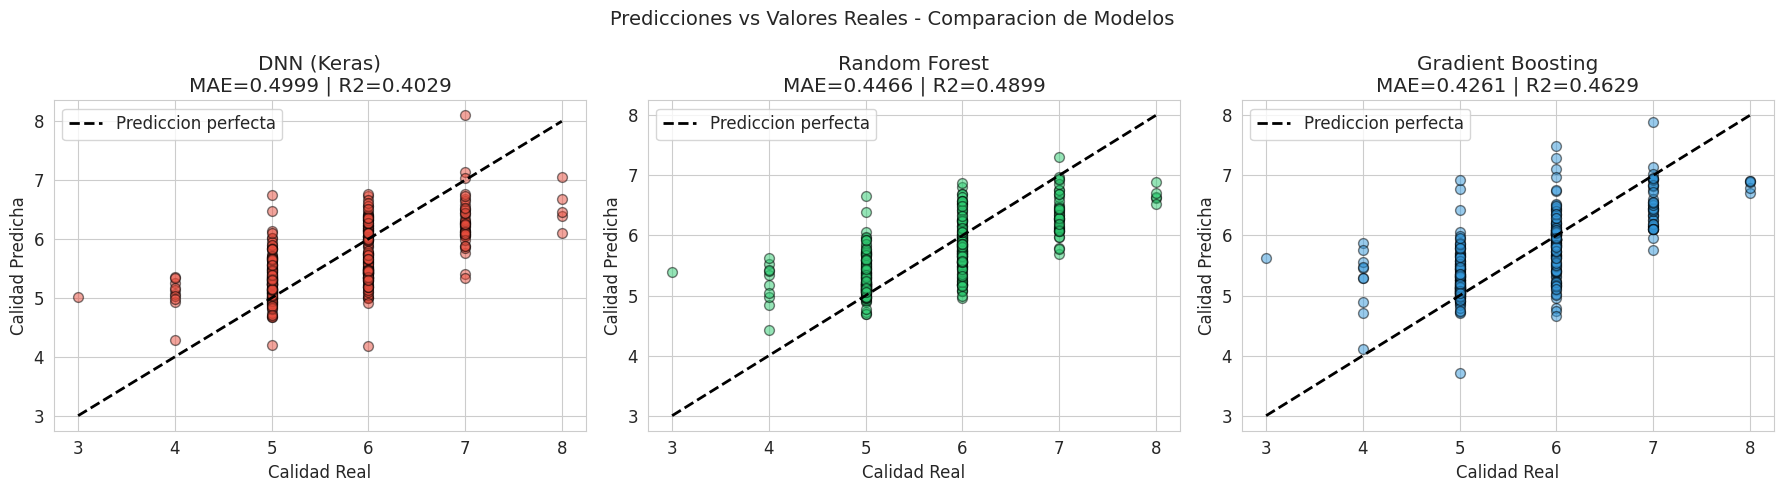

In [38]:
# Graficar predicciones vs valores reales para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos_comp = [
    ('DNN (Keras)', dnn_pred, '#e74c3c'),
    ('Random Forest', rf_pred, '#2ecc71'),
    ('Gradient Boosting', gb_pred, '#3498db')
]

for i, (nombre, predicciones, color) in enumerate(modelos_comp):
    axes[i].scatter(y_test, predicciones, alpha=0.5, color=color, edgecolors='black', s=50)
    axes[i].plot([3, 8], [3, 8], 'k--', linewidth=2, label='Prediccion perfecta')
    axes[i].set_xlabel('Calidad Real')
    axes[i].set_ylabel('Calidad Predicha')
    mae_val = mean_absolute_error(y_test, predicciones)
    r2_val = r2_score(y_test, predicciones)
    axes[i].set_title(f'{nombre}\nMAE={mae_val:.4f} | R2={r2_val:.4f}')
    axes[i].legend()
    axes[i].grid(True)

plt.suptitle('Predicciones vs Valores Reales - Comparacion de Modelos', fontsize=14)
plt.tight_layout()
plt.show()

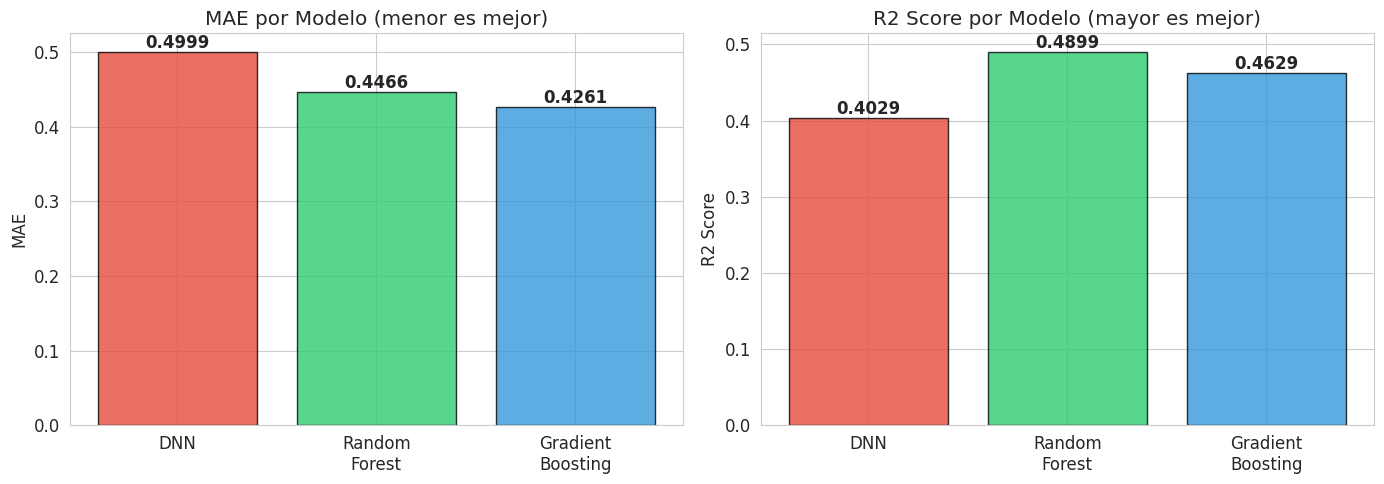

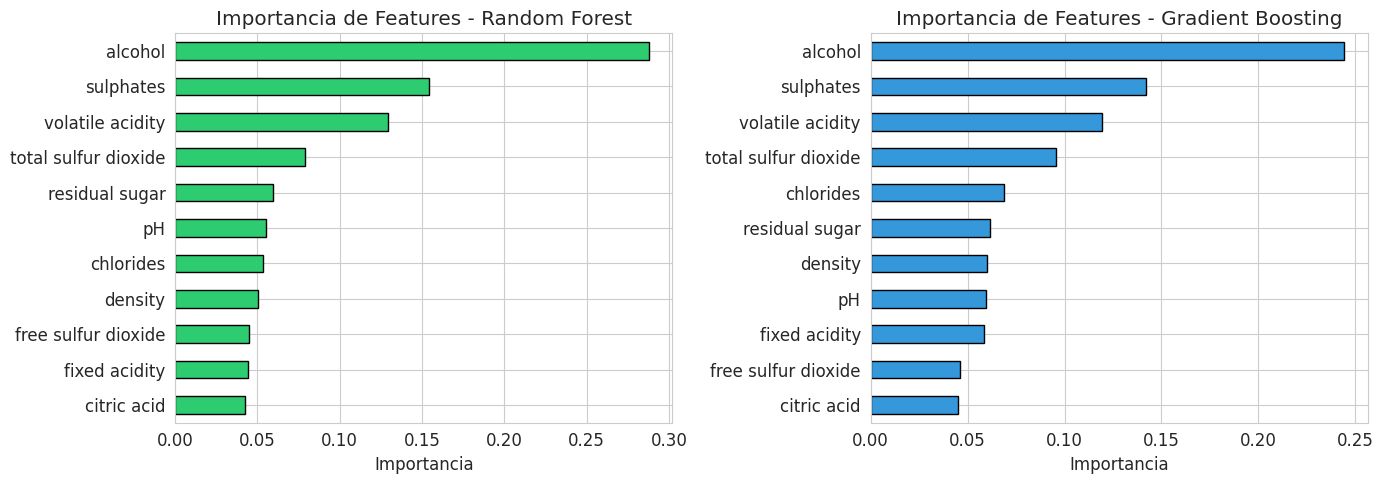

In [39]:
# Grafico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nombres_modelos = ['DNN', 'Random\nForest', 'Gradient\nBoosting']
colores_comp = ['#e74c3c', '#2ecc71', '#3498db']

# MAE
maes_comp = [dnn_mae, rf_mae, gb_mae]
bars = axes[0].bar(nombres_modelos, maes_comp, color=colores_comp, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE por Modelo (menor es mejor)')
for bar, val in zip(bars, maes_comp):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontweight='bold')

# R2
r2s_comp = [dnn_r2, rf_r2, gb_r2]
bars = axes[1].bar(nombres_modelos, r2s_comp, color=colores_comp, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('R2 Score')
axes[1].set_title('R2 Score por Modelo (mayor es mejor)')
for bar, val in zip(bars, r2s_comp):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Importancia de features (solo para modelos basados en arboles)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest feature importance
importancia_rf = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importancia_rf.plot(kind='barh', ax=axes[0], color='#2ecc71', edgecolor='black')
axes[0].set_title('Importancia de Features - Random Forest')
axes[0].set_xlabel('Importancia')

# Gradient Boosting feature importance
importancia_gb = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importancia_gb.plot(kind='barh', ax=axes[1], color='#3498db', edgecolor='black')
axes[1].set_title('Importancia de Features - Gradient Boosting')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.show()

### \u270d\ufe0f Pregunta - Experimento 6

**\u00bfLa DNN supero a los modelos clasicos? \u00bfEn que tipo de datos tabulares crees que Deep Learning tiene ventaja sobre ML clasico? \u00bfQue features resultaron mas importantes segun los modelos basados en arboles?**

### \u270d\ufe0f Tu respuesta:

*Escribe aqui tu respuesta...*

---
### Experimento 7: Transformar en Clasificacion

Hasta ahora hemos tratado la calidad del vino como un **valor continuo** (regresion). Pero, \u00bfque pasa si lo convertimos en un **problema de clasificacion**?

Vamos a crear 3 categorias:
- **Baja calidad:** puntuacion 3, 4 o 5
- **Media calidad:** puntuacion 6
- **Alta calidad:** puntuacion 7, 8 o 9

Distribucion de clases:
  Clase 0 (Baja (3-5)     ):  744 muestras (46.5%)
  Clase 1 (Media (6)      ):  638 muestras (39.9%)
  Clase 2 (Alta (7-9)     ):  217 muestras (13.6%)


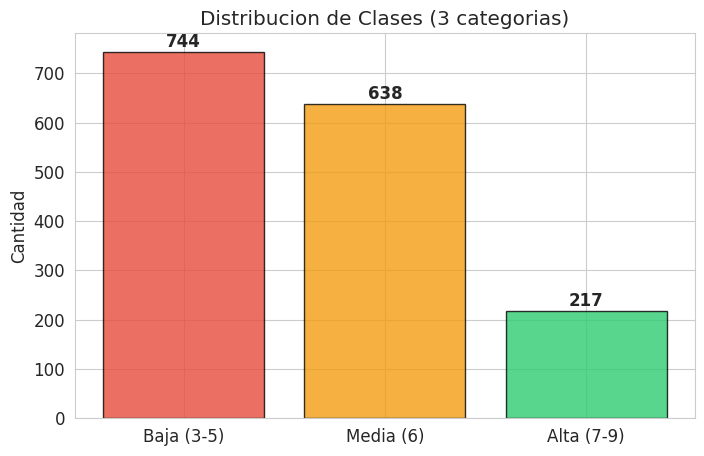

In [40]:
# ============================================================
# EXPERIMENTO 7: Transformar en Clasificacion
# ============================================================

# Paso 1: Crear las categorias
def categorizar_calidad(valor):
    """Convierte la calidad numerica en 3 categorias."""
    if valor <= 5:
        return 0  # Baja
    elif valor == 6:
        return 1  # Media
    else:
        return 2  # Alta

# Aplicar la categorizacion
y_cat = y.apply(categorizar_calidad)

# Verificar la distribucion
etiquetas = {0: 'Baja (3-5)', 1: 'Media (6)', 2: 'Alta (7-9)'}
print("Distribucion de clases:")
print("=" * 40)
for clase, nombre in etiquetas.items():
    n = (y_cat == clase).sum()
    print(f"  Clase {clase} ({nombre:15s}): {n:4d} muestras ({n/len(y_cat)*100:.1f}%)")

# Visualizar
plt.figure(figsize=(8, 5))
conteo_cat = y_cat.value_counts().sort_index()
bars = plt.bar([etiquetas[i] for i in conteo_cat.index], conteo_cat.values,
               color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black', alpha=0.8)
for bar, val in zip(bars, conteo_cat.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', fontweight='bold', fontsize=12)
plt.ylabel('Cantidad')
plt.title('Distribucion de Clases (3 categorias)')
plt.show()

In [41]:
# Paso 2: Dividir datos para clasificacion
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X, y_cat, test_size=0.20, random_state=SEED, stratify=y_cat  # stratify mantiene proporciones
)

X_train_cat, X_val_cat, y_train_cat, y_val_cat = train_test_split(
    X_train_cat, y_train_cat, test_size=0.25, random_state=SEED, stratify=y_train_cat
)

# Estandarizar
scaler_cat = StandardScaler()
X_train_cat_scaled = scaler_cat.fit_transform(X_train_cat)
X_val_cat_scaled = scaler_cat.transform(X_val_cat)
X_test_cat_scaled = scaler_cat.transform(X_test_cat)

# Convertir etiquetas a one-hot encoding para categorical_crossentropy
n_clases = 3
y_train_onehot = keras.utils.to_categorical(y_train_cat, n_clases)
y_val_onehot = keras.utils.to_categorical(y_val_cat, n_clases)
y_test_onehot = keras.utils.to_categorical(y_test_cat, n_clases)

print(f"Datos de entrenamiento: {X_train_cat_scaled.shape}")
print(f"Ejemplo de etiqueta one-hot: {y_train_onehot[0]} (clase {y_train_cat.iloc[0]})")

Datos de entrenamiento: (959, 11)
Ejemplo de etiqueta one-hot: [1. 0. 0.] (clase 0)


In [42]:
# Paso 3: Construir DNN de clasificacion
modelo_clf = keras.Sequential([
    # Capas ocultas (similares a la regresion)
    layers.Dense(128, activation='relu', input_shape=(X_train_cat_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),

    # Capa de salida para CLASIFICACION MULTICLASE:
    # - 3 neuronas (una por clase)
    # - Activacion SOFTMAX (convierte en probabilidades que suman 1)
    layers.Dense(n_clases, activation='softmax', name='salida_clasificacion')
], name='modelo_clasificacion')

# Compilar para clasificacion
modelo_clf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',     # Perdida para clasificacion multiclase
    metrics=['accuracy']                  # Metrica principal: accuracy
)

modelo_clf.summary()

print("\nDiferencias clave con el modelo de regresion:")
print("  - Capa de salida: 3 neuronas con softmax (antes: 1 sin activacion)")
print("  - Loss: categorical_crossentropy (antes: mse)")
print("  - Metrica: accuracy (antes: mae)")

Model: "modelo_clasificacion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_clasificacion (Dense)    │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,739 (49.76 KB)

 Trainable params: 12,355 (48.26 KB)

 Non-trainable params: 384 (1.50 KB)


Diferencias clave con el modelo de regresion:
  - Capa de salida: 3 neuronas con softmax (antes: 1 sin activacion)
  - Loss: categorical_crossentropy (antes: mse)
  - Metrica: accuracy (antes: mae)


In [43]:
# Paso 4: Entrenar
print("Entrenando DNN de clasificacion...")
historia_clf = modelo_clf.fit(
    X_train_cat_scaled, y_train_onehot,
    validation_data=(X_val_cat_scaled, y_val_onehot),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    ]
)

print("\nEntrenamiento completado.")

Entrenando DNN de clasificacion...
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.4785 - loss: 1.1435 - val_accuracy: 0.5344 - val_loss: 0.9801
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5725 - loss: 0.9242 - val_accuracy: 0.5969 - val_loss: 0.9248
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6044 - loss: 0.8160 - val_accuracy: 0.6438 - val_loss: 0.8876
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6045 - loss: 0.8274 - val_accuracy: 0.6219 - val_loss: 0.8600
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6395 - loss: 0.7731 - val_accuracy: 0.6406 - val_loss: 0.8363
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6433 - loss: 0.7471 - val_accuracy: 0.6187 - val_loss: 0.8169
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6634 - loss: 0.7020 - val_accuracy: 0.6281 - val_loss: 0.8054
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6390 - lo

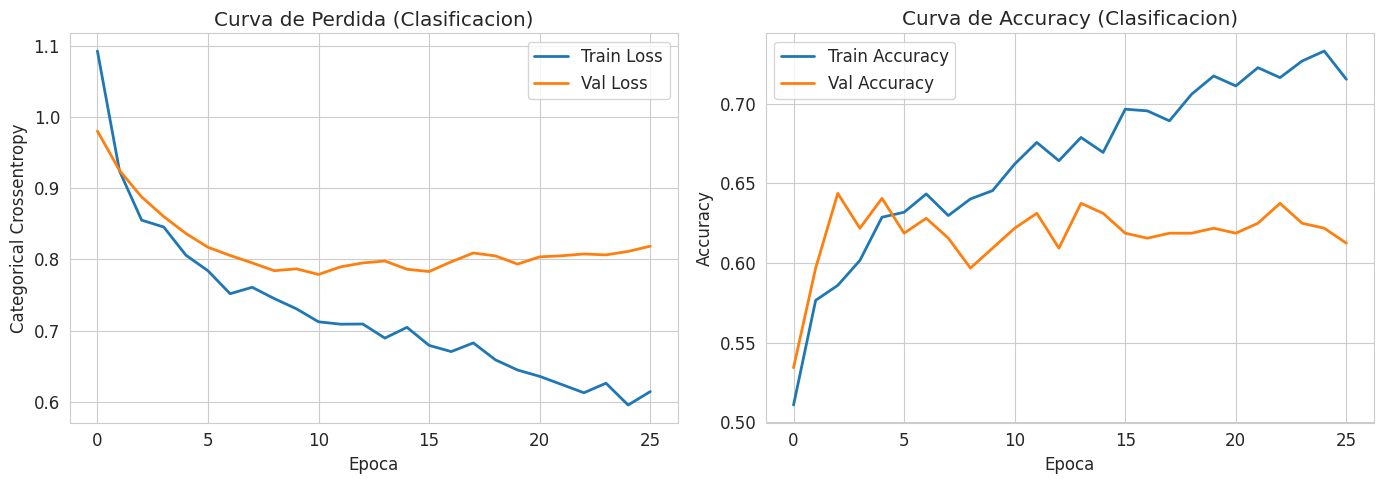

In [44]:
# Paso 5: Graficar curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de perdida
axes[0].plot(historia_clf.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(historia_clf.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Categorical Crossentropy')
axes[0].set_title('Curva de Perdida (Clasificacion)')
axes[0].legend()
axes[0].grid(True)

# Curva de accuracy
axes[1].plot(historia_clf.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(historia_clf.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curva de Accuracy (Clasificacion)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [45]:
# Paso 6: Evaluar con matriz de confusion y classification_report

# Obtener predicciones
y_pred_proba = modelo_clf.predict(X_test_cat_scaled, verbose=0)
y_pred_clases = np.argmax(y_pred_proba, axis=1)  # Convertir probabilidades a clases

# Accuracy en test
test_loss, test_acc = modelo_clf.evaluate(X_test_cat_scaled, y_test_onehot, verbose=0)
print(f"Resultados en TEST:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")

# Classification Report
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
nombres_clases = ['Baja (3-5)', 'Media (6)', 'Alta (7-9)']
print(classification_report(y_test_cat, y_pred_clases, target_names=nombres_clases))

Resultados en TEST:
  Loss: 0.7295
  Accuracy: 0.6344 (63.4%)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Baja (3-5)       0.74      0.76      0.75       149
   Media (6)       0.54      0.58      0.56       128
  Alta (7-9)       0.50      0.37      0.43        43

    accuracy                           0.63       320
   macro avg       0.60      0.57      0.58       320
weighted avg       0.63      0.63      0.63       320



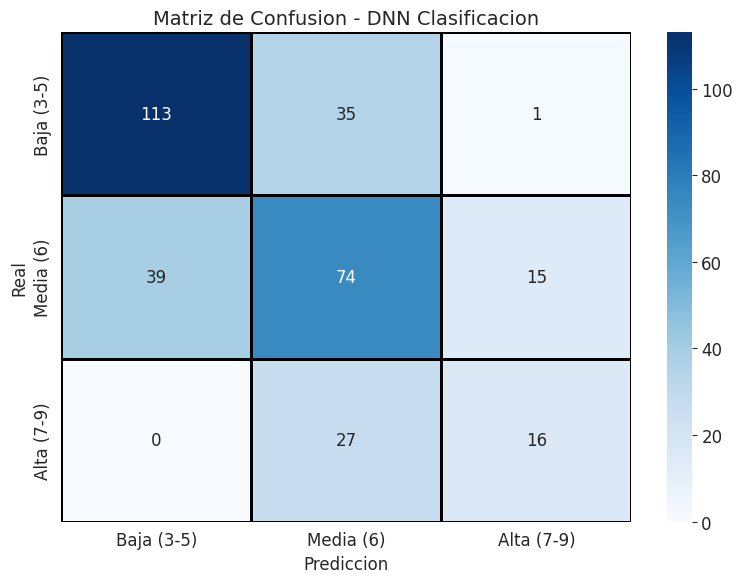


Interpretacion de la Matriz de Confusion:
  Baja (3-5): 113/149 clasificados correctamente (75.8%)
  Media (6): 74/128 clasificados correctamente (57.8%)
  Alta (7-9): 16/43 clasificados correctamente (37.2%)


In [46]:
# Matriz de confusion
cm = confusion_matrix(y_test_cat, y_pred_clases)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases,
            linewidths=1, linecolor='black')
plt.xlabel('Prediccion', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusion - DNN Clasificacion', fontsize=14)
plt.tight_layout()
plt.show()

# Interpretacion
print("\nInterpretacion de la Matriz de Confusion:")
for i, nombre in enumerate(nombres_clases):
    total = cm[i].sum()
    correctos = cm[i][i]
    print(f"  {nombre}: {correctos}/{total} clasificados correctamente ({correctos/total*100:.1f}%)")

### \u270d\ufe0f Pregunta - Experimento 7

**\u00bfCambio significativamente el rendimiento al tratar el problema como clasificacion en vez de regresion? \u00bfQue clase fue la mas dificil de predecir? \u00bfCuando conviene tratar un problema como regresion vs clasificacion?**

*Pista: Mira la precision (precision), recall y f1-score de cada clase en el classification report.*

### \u270d\ufe0f Tu respuesta:

*Escribe aqui tu respuesta...*

---
## 5. Sintesis y Reflexion Final

Has completado una guia extensa donde aplicaste redes neuronales profundas a un problema real con datos tabulares. Es hora de reflexionar sobre lo aprendido.

### \u270d\ufe0f Pregunta de Sintesis 1

**Describe el pipeline completo para aplicar DNN a un dataset tabular nuevo (desde que recibes los datos crudos hasta que guardas el modelo listo para produccion).**

*Incluye todos los pasos: EDA, preprocesamiento, arquitectura, entrenamiento, evaluacion, guardado.*

### \u270d\ufe0f Tu respuesta:

Cuando recibo un dataset tabular nuevo, lo primero que hago es explorar los datos con un análisis exploratorio osea el EDA, en esta etapa reviso cómo están distribuidas las variables si hay valores faltantes si hay outliers y cómo se relacionan las variables con la variable objetivo y también miro estadísticas básicas y hago algunos gráficos para entender mejor el dataset.

Después viene el preprocesamiento y aquí limpio los datos si es necesario, manejo valores faltantes, separo las variables en X y Y, luego divido el dataset en entrenamiento, validación y test.

Luego diseño la arquitectura de la red neuronal, normalmente empiezo con varias capas densas con activación ReLU, y puedo agregar técnicas como Batch Normalization o Dropout para mejorar el entrenamiento y evitar overfitting. La capa de salida depende del problema si es regresión uso una neurona sin activación y si es clasificación uso varias neuronas con softmax.

Después compilo el modelo definiendo el optimizador por ejemplo Adam, la función de pérdida adecuada como MSE para regresión o categorical crossentropy para clasificación y las métricas que quiero medir.

Luego entreno el modelo con model.fit(), usando datos de validación y callbacks como EarlyStopping para evitar overfitting tambien durante el entrenamiento reviso las curvas de pérdida y métricas para ver si el modelo está aprendiendo correctamente y ya una vez entrenado evalúo el modelo con el conjunto de test usando métricas adecuadas.

Finalmente si el modelo funciona bien lo guardo usando model.save() para poder cargarlo después y usarlo.

### \u270d\ufe0f Pregunta de Sintesis 2

**\u00bfEn que situaciones NO recomendarias usar Deep Learning para datos tabulares? Menciona al menos 3 escenarios concretos y explica por que un modelo clasico seria mejor.**

### \u270d\ufe0f Tu respuesta:

 para nosotros Hay varios escenarios donde un modelo clásico puede ser mejor.

El primero seria cuando el dataset es pequeño porque las redes neuronales suelen necesitar muchos datos para aprender bien y si el dataset tiene pocas muestras es muy fácil que el modelo tenga overfitting, en esos casos modelos como Random Forest o Gradient Boosting suelen funcionar mejor.

El segundo caso seria cuando el problema necesita mucha interpretabilidad porque las redes neuronales son más difíciles de interpretar, mientras que modelos como árboles de decisión o regresión lineal permiten entender mejor qué variables influyen en el resultado.

 El tercero es cuando los datos son tabulares simples y no son muy complejos, en muchos datasets tabulares modelos como XGBoost o Random Forest suelen obtener mejores resultados con menos esfuerzo y menor tiempo de entrenamiento que una red neuronal.

Es Por eso que en muchos proyectos de ciencia de datos primero se prueban modelos clásicos antes de usar Deep Learning.

### \u270d\ufe0f Pregunta de Sintesis 3

**\u00bfQue callbacks usarias SIEMPRE en un proyecto real de Deep Learning y por que? Ordenalos de mayor a menor importancia segun tu criterio.**

### \u270d\ufe0f Tu respuesta:

Los callbacks que siempre usariamos en un proyecto de deep learning serían:

El primero seria EarlyStopping porque evita que el modelo siga entrenando cuando ya no está mejorando y nos dé así la mejor epoca. Ayudandonos a prevenir overfitting y ahorrando tiempo de entrenamiento.

En segundo lugar usariamos ModelCheckpoint porque guarda automáticamente el mejor modelo durante el entrenamiento y así aunque el modelo empeore después, siempre nos guardada la mejor versión.

En tercer lugar usaría ReduceLROnPlateau, que reduce el learning rate cuando el modelo deja de mejorar, esto ayuda a que el entrenamiento haga un ajuste más preciso y a veces mejora bastante el rendimiento final.

por ultimo también nos puede ser útil CSVLogger, que guarda el historial del entrenamiento en un archivo, esto no afecta el aprendizaje del modelo pero es muy útil para analizar los resultados después.

---
## 6. Reto Extra

### Prediccion de Precios de Viviendas con DNN

Aplica todo lo aprendido en esta guia al dataset **California Housing** de scikit-learn.

**Instrucciones:**
1. Cargar el dataset con `sklearn.datasets.fetch_california_housing()`
2. Realizar un EDA completo (distribuciones, correlaciones, outliers)
3. Preprocesar los datos (estandarizar, dividir en train/val/test)
4. Disenar y entrenar una DNN para regresion con callbacks (ModelCheckpoint, ReduceLROnPlateau, EarlyStopping)
5. Evaluar con MAE, MSE, R2
6. Comparar con un RandomForest
7. Visualizar predicciones vs valores reales

**Tienes libertad para elegir:**
- La arquitectura de la red (numero de capas, neuronas, dropout, etc.)
- Los hiperparametros (learning rate, batch size, etc.)
- Las visualizaciones adicionales que quieras agregar

**Objetivo:** Obtener el menor MAE posible en el conjunto de test.

In [47]:
# ============================================================
# RETO EXTRA: California Housing
# ============================================================
from sklearn.datasets import fetch_california_housing

# Cargar el dataset
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing['MedHouseVal'] = housing.target  # Valor mediano de la vivienda (en cientos de miles de dolares)

print("Dataset California Housing cargado.")
print(f"Dimensiones: {df_housing.shape}")
print(f"\nDescripcion: {housing.DESCR[:500]}")
print("\nPrimeras 5 filas:")
df_housing.head()

Dataset California Housing cargado.
Dimensiones: (20640, 9)

Descripcion: .. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group popu

Primeras 5 filas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Estadísticas descriptivas del dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


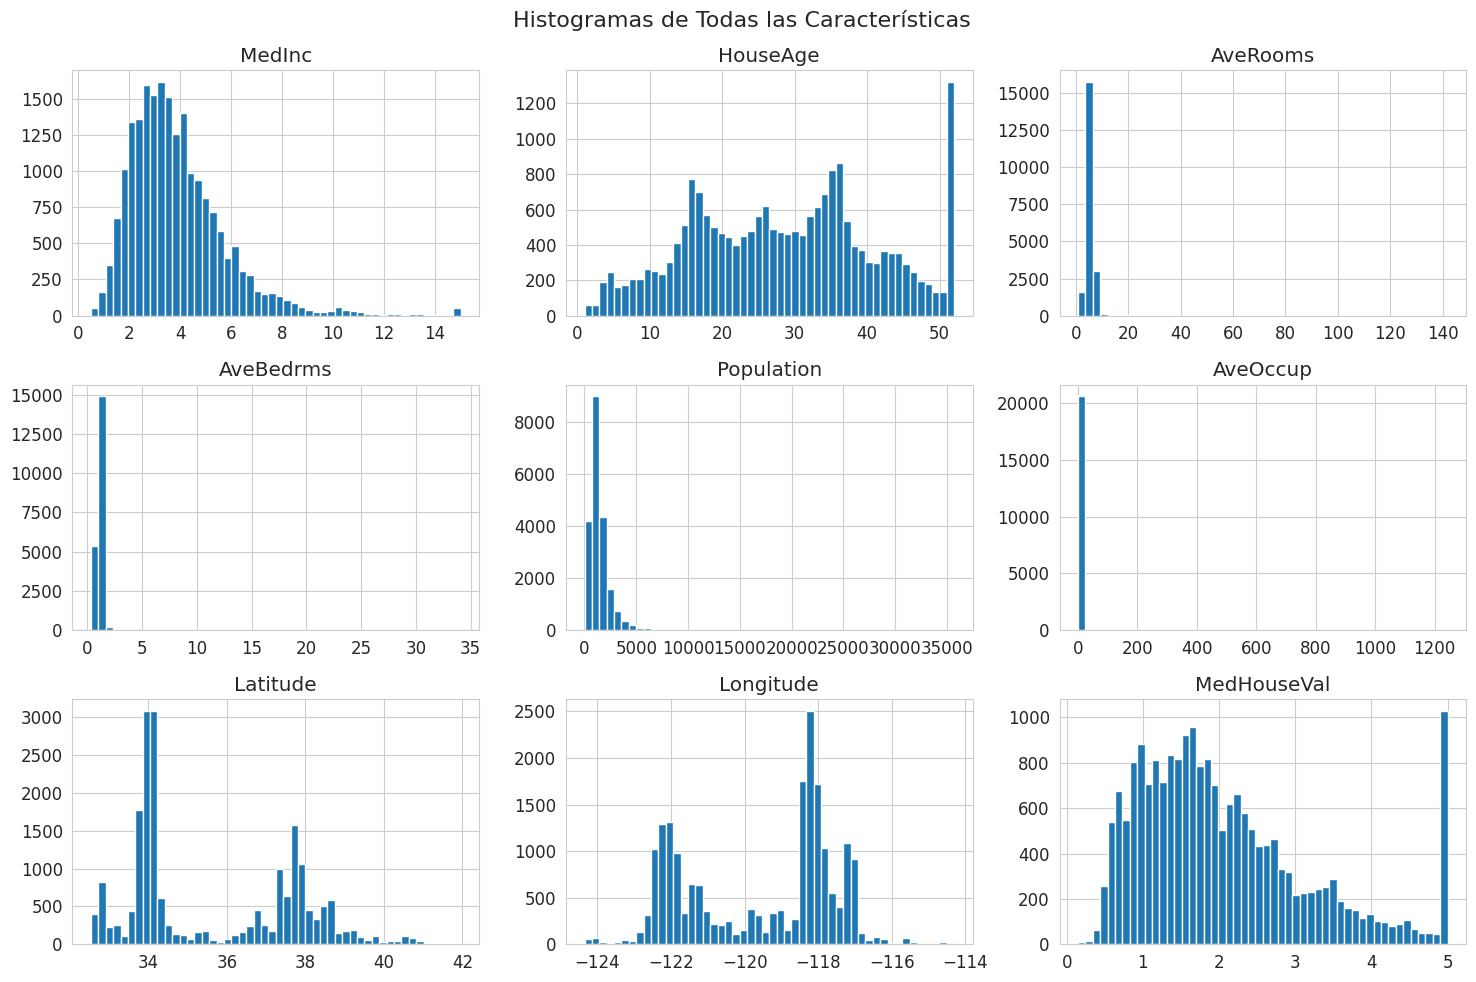

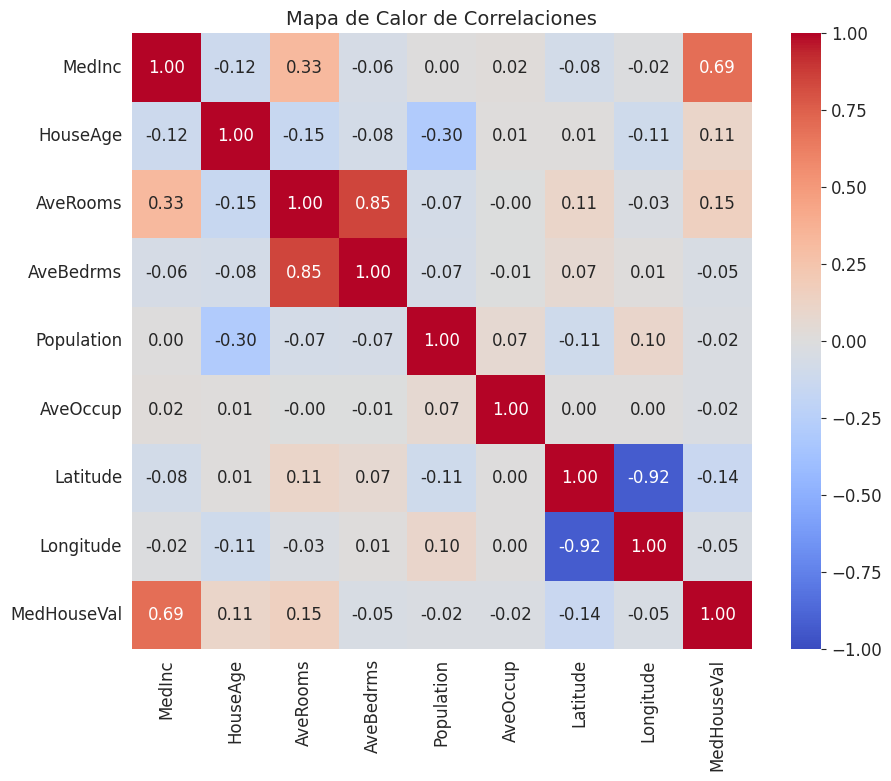

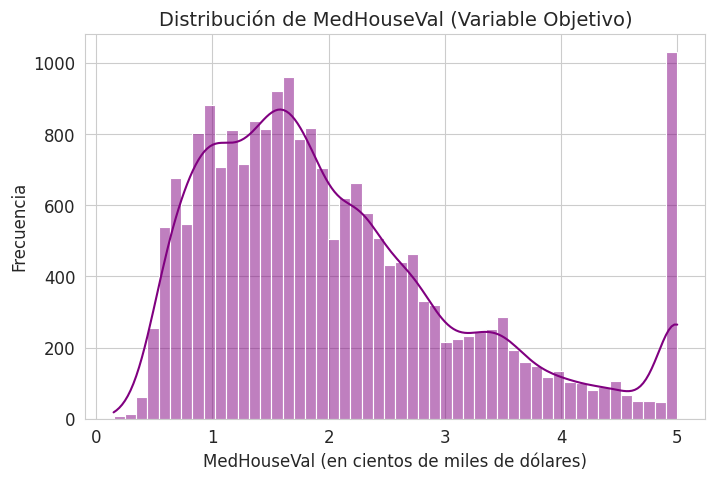

In [48]:
# Tu codigo aqui:

import matplotlib.pyplot as plt
import seaborn as sns

# - describe()
print("Estadísticas descriptivas del dataset:")
display(df_housing.describe())

# - Histogramas de todas las features
df_housing.hist(bins=50, figsize=(15, 10))
plt.suptitle('Histogramas de Todas las Características', fontsize=16)
plt.tight_layout()
plt.show()

# - Mapa de calor de correlaciones
plt.figure(figsize=(10, 8))
# Utilizamos seaborn para un mapa de color más estético
sns.heatmap(df_housing.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Mapa de Calor de Correlaciones', fontsize=14)
plt.show()

# - Distribución de la variable objetivo
plt.figure(figsize=(8, 5))
sns.histplot(df_housing['MedHouseVal'], bins=50, kde=True, color='purple')
plt.title('Distribución de MedHouseVal (Variable Objetivo)', fontsize=14)
plt.xlabel('MedHouseVal (en cientos de miles de dólares)')
plt.ylabel('Frecuencia')
plt.show()


In [49]:
# Tu codigo aqui:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# - Separar X e y
X = df_housing.drop('MedHouseVal', axis=1)
y = df_housing['MedHouseVal']

# - Train/Val/Test split (60% Entrenamiento, 20% Validación, 20% Prueba)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42) # 0.25 * 0.8 = 0.2

print(f"Tamaño de Entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño de Validación: {X_val.shape[0]} muestras")
print(f"Tamaño de Prueba: {X_test.shape[0]} muestras")

# - StandardScaler
scaler = StandardScaler()

# Ajustar en datos de entrenamiento y transformar
X_train_scaled = scaler.fit_transform(X_train)

# Solo transformar validación y prueba (evitando fuga de datos)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



Tamaño de Entrenamiento: 12384 muestras
Tamaño de Validación: 4128 muestras
Tamaño de Prueba: 4128 muestras


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,361 (185.00 KB)

 Trainable params: 46,465 (181.50 KB)

 Non-trainable params: 896 (3.50 KB)


Iniciando entrenamiento...
Epoch 1/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 2.8920 - mae: 1.2659 - val_loss: 1.2318 - val_mae: 0.7721 - learning_rate: 0.0010
Epoch 2/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6615 - mae: 0.5986 - val_loss: 0.5607 - val_mae: 0.5267 - learning_rate: 0.0010
Epoch 3/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5540 - mae: 0.5490 - val_loss: 0.5029 - val_mae: 0.4766 - learning_rate: 0.0010
Epoch 4/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4884 - mae: 0.5125 - val_loss: 0.4587 - val_mae: 0.4495 - learning_rate: 0.0010
Epoch 5/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4455 - mae: 0.4843 - val_loss: 0.3814 - val_mae: 0.4313 - learning_rate: 0.0010
Epoch 6/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4262 - mae: 0.4716 - val_loss: 0.3649 - val_mae: 0.4212 - learning_rate: 0.0010
Epoch 7/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4196 - mae: 0.4700 - val_loss: 0.4003 - val_mae: 

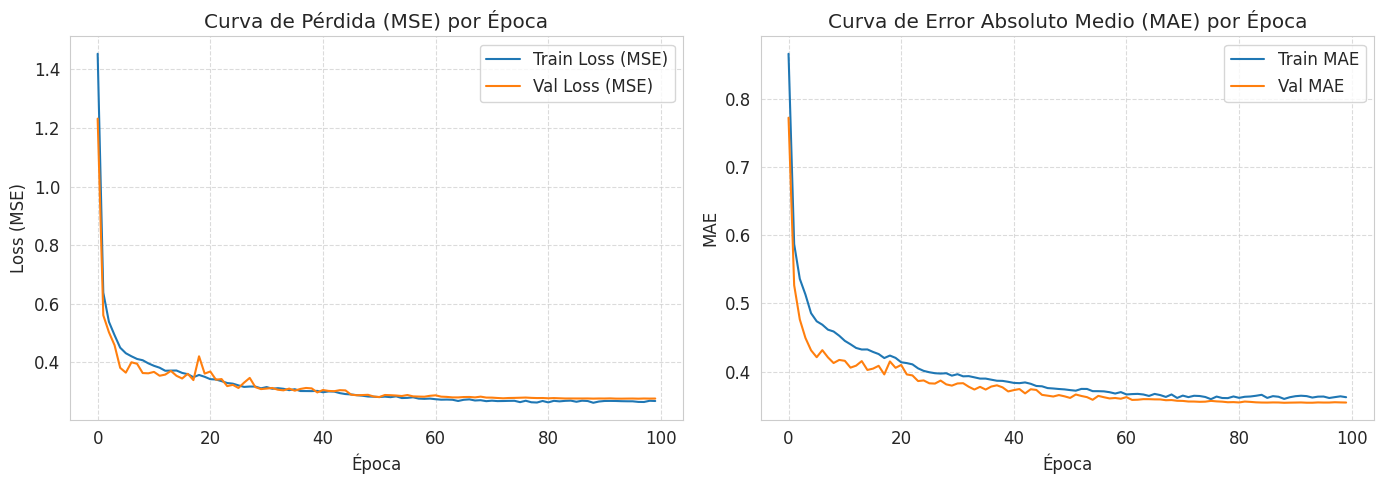

In [50]:
# Tu codigo aqui: Disenar y entrenar la DNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import os

tf.random.set_seed(42)

# - Definir la arquitectura
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),

    # Capa de salida (1 neurona sin activación para Regresión)
    Dense(1)
])

model.summary()

# - Compilar
# Para regresión comúnmente optimizamos MSE pero evaluamos también con MAE
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mse',
              metrics=['mae'])

# Crear directorio para guardar modelos temporales si no existe
os.makedirs('modelos', exist_ok=True)

# - Callbacks
checkpoint_cb = ModelCheckpoint("modelos/mejor_dnn_housing.keras", save_best_only=True, monitor='val_loss')
# Reduce el LR si el val_loss no mejora después de 5 épocas
reduce_lr_cb = ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-5, monitor='val_loss', verbose=1)
# Detiene el entrenamiento si no hay mejora tras 15 épocas
early_stopping_cb = EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss', verbose=1)

# - Entrenar
print("\nIniciando entrenamiento...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_scaled, y_val),
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stopping_cb],
    verbose=1
)

# - Graficar curvas de entrenamiento
plt.figure(figsize=(14, 5))

# Gráfico de la Función de Pérdida (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Curva de Pérdida (MSE) por Época')
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfico del Error Absoluto Medio (MAE)
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Curva de Error Absoluto Medio (MAE) por Época')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()




129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Entrenando Random Forest para comparar...

--- Tabla Comparativa de Rendimiento en Conjunto de Prueba ---


,Modelo,MAE,MSE,R² Score
0,Red Neuronal Profunda (DNN),0.3497,0.2759,0.7895
1,Random Forest,0.3275,0.2554,0.8051


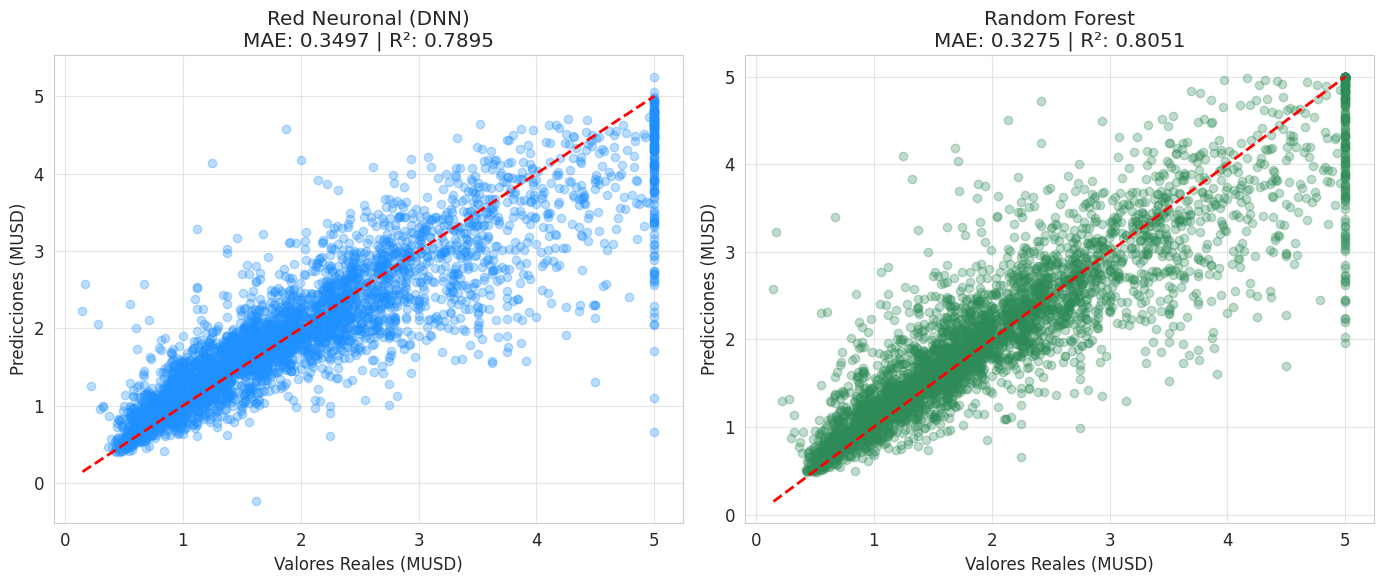

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

# ---------------------------------------------------------
# - Evaluar DNN en test
# ---------------------------------------------------------
y_pred_dnn = model.predict(X_test_scaled).flatten()

mae_dnn = mean_absolute_error(y_test, y_pred_dnn)
mse_dnn = mean_squared_error(y_test, y_pred_dnn)
r2_dnn = r2_score(y_test, y_pred_dnn)

# ---------------------------------------------------------
# - Entrenar y evaluar RandomForest
# ---------------------------------------------------------
print("Entrenando Random Forest para comparar...")
# Usamos Random Forest con 100 estimadores
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
# Al Random Forest normalmente no le afecta la escala de los datos,
# pero le pasaremos los datos sin escalar tal como salieron del split
rf_model.fit(X_train_full, y_train_full) # Lo entrenamos usando train + val para ser justos

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# ---------------------------------------------------------
# - Tabla comparativa
# ---------------------------------------------------------
resultados = pd.DataFrame({
    'Modelo': ['Red Neuronal Profunda (DNN)', 'Random Forest'],
    'MAE': [mae_dnn, mae_rf],
    'MSE': [mse_dnn, mse_rf],
    'R² Score': [r2_dnn, r2_rf]
})

print("\n--- Tabla Comparativa de Rendimiento en Conjunto de Prueba ---")
display(resultados.round(4))

# ---------------------------------------------------------
# - Graficar predicciones vs reales
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))

# Gráfica DNN
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_dnn, alpha=0.3, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')
plt.title(f'Red Neuronal (DNN)\nMAE: {mae_dnn:.4f} | R²: {r2_dnn:.4f}')
plt.xlabel('Valores Reales (MUSD)')
plt.ylabel('Predicciones (MUSD)')
plt.grid(True, alpha=0.5)

# Gráfica Random Forest
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')
plt.title(f'Random Forest\nMAE: {mae_rf:.4f} | R²: {r2_rf:.4f}')
plt.xlabel('Valores Reales (MUSD)')
plt.ylabel('Predicciones (MUSD)')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()




---
## 7. Referencias

1. **Chollet, F.** (2021). *Deep Learning with Python* (2nd Edition). Manning Publications.
2. **Geron, A.** (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd Edition). O'Reilly Media.
3. **Keras Documentation** - Callbacks. https://keras.io/api/callbacks/
4. **Keras Documentation** - Save and load models. https://keras.io/guides/serialization_and_saving/
5. **UCI Machine Learning Repository** - Wine Quality Dataset. https://archive.ics.uci.edu/ml/datasets/wine+quality
6. **Shwartz-Ziv, R., & Armon, A.** (2022). Tabular data: Deep learning is not all you need. *Information Fusion*, 81, 84-90.
7. **Grinsztajn, L., Oyallon, E., & Varoquaux, G.** (2022). Why do tree-based models still outperform deep learning on tabular data? *NeurIPS 2022*.

---

**Fin de la Guia 04** | Siguiente: Guia 05

In [ ]:
# Limpieza de archivos temporales (opcional)
# Descomenta las siguientes lineas si deseas limpiar los archivos generados
# import shutil
# shutil.rmtree('modelos', ignore_errors=True)
# shutil.rmtree('logs', ignore_errors=True)
print("Guia 04 completada. Buen trabajo!")